# 📜 Classical NLP — Text as Data, Strong Baselines, and the Road to Embeddings

> **What you'll learn:** how to turn raw text into something a model can use — tokenization, normalization, stopwords, stemming and lemmatization, spaCy pipelines (POS tags, entities, dependency trees, rules), bag-of-words and TF-IDF, Naive Bayes and logistic regression baselines, word2vec and FastText, and LDA topic models — plus the judgment to know when these cheap tools still beat an LLM.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate (one 🔴 section) |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) (pipelines, cross-validation, logistic regression) |
| **Tested with** | Python 3.12 · nltk 3.10 · spaCy 3.8 (`en_core_web_sm`) · gensim 4.4 · scikit-learn 1.9 · tiktoken 0.14 · sentence-transformers 6.0 |
| **Interview relevance** | ⭐⭐⭐ High — "build a text classifier baseline", TF-IDF and Naive Bayes from scratch, stemming vs lemmatization, word2vec and negative sampling, BPE vs WordPiece, "when would you NOT use an LLM?" |

## 🤔 What Is Classical NLP?

**NLP** (Natural Language Processing) is teaching computers to work with human language: sort emails, find names in documents, answer questions.

Computers only understand numbers, so every NLP system has to answer one question first: **how do we turn text into numbers?**

**Classical NLP** is the toolbox people built *before* large language models (LLMs): rules, word counts, small statistical models, and the first word embeddings. Think of it like cooking:

- A **modern LLM** is a restaurant kitchen: it can make anything, but it is expensive, slow to start, and you can't see exactly what went into the dish.
- **Classical NLP** is a sharp knife and a cutting board: simple, fast, cheap, and you know exactly what every step does. Most great meals still start with good knife work.

```
raw text → clean → split into tokens → normalize → turn into numbers → model → prediction
 "Wasn't   "wasn't  ["was", "n't",     ["be",       [0, 1, 0, 2 …]    Naive   "negative"
  great!"   great!"   "great", "!"]     "not","great"]                Bayes
```

Every box in that picture is a decision you will learn to make in this notebook.

## 🎯 Why It Matters

- **Strong, cheap baselines.** TF-IDF + logistic regression trains in seconds on a laptop, predicts in well under a millisecond, and is often within a few points of a fine-tuned transformer on topic classification. Teams ship it first and only move to bigger models when the numbers justify the cost.
- **Preprocessing judgment.** Retrieval systems (like the BM25 half of hybrid search in RAG), search engines, and data-cleaning pipelines all depend on tokenization and normalization choices. Removing the wrong stopwords can quietly flip "not good" into "good".
- **Structure extraction.** spaCy's named entities, dependency trees, and rule matchers still power information extraction in production (invoices, medical notes, logs), often as a fast pre-filter before an LLM.
- **The ideas behind embeddings.** Word2vec's "a word is known by the company it keeps" is the direct ancestor of the sentence embeddings used in semantic search and RAG ([next notebook](02_Embeddings_and_Semantic_Search.ipynb)). Subword tokenization is what every LLM does before anything else.
- **In interviews** you will be asked to build a text classifier baseline and justify it, implement TF-IDF or Naive Bayes from scratch, explain word2vec's training objective, compare BPE and WordPiece, and argue when a classical model beats an LLM on cost, latency, or data size.

## ✅ By the End You Can

- [ ] Build a preprocessing pipeline and explain each choice (tokenizer, casing, stopwords, stemming vs lemmatization)
- [ ] Explain why LLMs use subword tokenizers (BPE, WordPiece) and show what they do to rare words
- [ ] Use spaCy efficiently (`nlp.pipe`, `select_pipes`) for POS tags, entities, dependency parses, and rule-based matching
- [ ] Implement TF-IDF and Multinomial Naive Bayes from scratch and prove they match scikit-learn
- [ ] Train word2vec and FastText, explain skip-gram with negative sampling, and name the limits of static word vectors
- [ ] Fit an LDA topic model, choose the number of topics with coherence, and label topics from data — and argue when classical NLP beats an LLM

## 📋 Table of Contents

1. [Text as Data and the Preprocessing Pipeline](#1.-Text-as-Data-and-the-Preprocessing-Pipeline-🟢)
2. [Tokenization: Words and Sentences](#2.-Tokenization:-Words-and-Sentences-🟢)
3. [Subword Tokenization: Why LLMs Use It](#3.-Subword-Tokenization:-Why-LLMs-Use-It-🟡)
4. [Normalization and Stopwords](#4.-Normalization-and-Stopwords-🟢)
5. [Stemming vs Lemmatization](#5.-Stemming-vs-Lemmatization-🟢)
6. [spaCy Pipelines and POS Tagging](#6.-spaCy-Pipelines-and-POS-Tagging-🟡)
7. [Named Entity Recognition](#7.-Named-Entity-Recognition-🟢)
8. [Dependency Parsing](#8.-Dependency-Parsing-🟡)
9. [Rule-Based Matching: Matcher and EntityRuler](#9.-Rule-Based-Matching:-Matcher-and-EntityRuler-🟡)
10. [Bag-of-Words, n-grams, and TF-IDF](#10.-Bag-of-Words,-n-grams,-and-TF-IDF-🟢)
11. [Naive Bayes and Logistic Regression Baselines](#11.-Naive-Bayes-and-Logistic-Regression-Baselines-🟡)
12. [Word2Vec: Skip-Gram and Negative Sampling](#12.-Word2Vec:-Skip-Gram-and-Negative-Sampling-🟡)
13. [FastText: Subword Word Vectors](#13.-FastText:-Subword-Word-Vectors-🟡)
14. [Topic Modeling with LDA](#14.-Topic-Modeling-with-LDA-🔴)
15. [When Classical NLP Still Wins](#15.-When-Classical-NLP-Still-Wins-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Newsgroup-Classifier-and-Entity-Extractor) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` lines, run them once, then restart the kernel.

**Downloads (first run only, about 120 MB in total, all cached afterwards):**
- NLTK data packages (~32 MB → `~/nltk_data`): only the four we use — `punkt_tab` (sentence splitter), `stopwords`, `wordnet` (lemmatizer dictionary), `averaged_perceptron_tagger_eng` (POS tagger).
- The 20 Newsgroups dataset (~14 MB) via scikit-learn, and Rotten Tomatoes movie reviews (~1 MB) via Hugging Face `datasets`.
- GloVe 50-d word vectors (66 MB) via `gensim.downloader`, BERT's and GPT-4o's tokenizer vocabularies (a few MB), and `all-MiniLM-L6-v2` (91 MB) in section 15.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "nltk>=3.9" "spacy>=3.8" "gensim>=4.3" "scikit-learn>=1.5" "datasets>=3" "tiktoken>=0.8" "sentence-transformers>=5" matplotlib pandas
# %pip install -q https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

import contextlib
import io
import math
import pickle
import re
import sys
import time
from collections import Counter
from pathlib import Path

import gensim
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import sklearn
import spacy
from huggingface_hub.utils import logging as hf_logging
from sklearn.datasets import fetch_20newsgroups
from transformers.utils import logging as transformers_logging

print(f"Python {sys.version.split()[0]} | nltk {nltk.__version__} | spaCy {spacy.__version__} | "
      f"gensim {gensim.__version__} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

# Download only the NLTK data we use, and only if it is not already on disk.
NLTK_PACKAGES = {"punkt_tab": "tokenizers/punkt_tab", "stopwords": "corpora/stopwords",
                 "wordnet": "corpora/wordnet", "averaged_perceptron_tagger_eng": "taggers/averaged_perceptron_tagger_eng"}
for package, resource in NLTK_PACKAGES.items():
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(package, quiet=True)
print("NLTK data ready:", ", ".join(NLTK_PACKAGES))

# The Hugging Face Hub prints a notice for anonymous downloads; set HF_TOKEN if you download a lot.
hf_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()          # hide the per-load "Loading weights" bar (downloads still show progress)

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_colwidth", 80)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    exp_arr = np.asarray(expected, dtype=object)
    numeric = all(isinstance(x, (int, float, np.integer, np.floating)) and not isinstance(x, bool)
                  for x in exp_arr.ravel())
    if numeric:
        try:
            got_arr = np.asarray(got, dtype=float)
            ok = got_arr.shape == exp_arr.shape and np.allclose(got_arr, exp_arr.astype(float), rtol=1e-5, atol=1e-6)
        except (TypeError, ValueError):
            ok = False
    else:
        def norm(x):
            return [tuple(i) if isinstance(i, (list, tuple)) else i for i in x] if isinstance(x, (list, tuple)) else x
        ok = norm(got) == norm(expected)
    assert ok, f"❌ {name}: got {got!r} — not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | nltk 3.10.3 | spaCy 3.8.16 | gensim 4.4.0 | scikit-learn 1.9.1 | pandas 3.0.5
NLTK data ready: punkt_tab, stopwords, wordnet, averaged_perceptron_tagger_eng


## 1. Text as Data and the Preprocessing Pipeline 🟢

Our main dataset is **20 Newsgroups**: ~18,800 real posts from 1990s Usenet discussion groups, each labeled with the group it was posted to. We use six clearly different groups so results are easy to interpret.

One important detail: we pass `remove=("headers", "footers", "quotes")`. Raw posts contain headers like `Newsgroups: rec.autos` and signatures that give the label away — a model trained on them learns to read the header, not the text. (Pitfall 1 measures how much this inflates accuracy.)

In [2]:
CATEGORIES = ["comp.graphics", "rec.autos", "rec.sport.hockey", "sci.med", "sci.space", "talk.politics.guns"]
news_train = fetch_20newsgroups(subset="train", categories=CATEGORIES, remove=("headers", "footers", "quotes"), random_state=SEED)
news_test = fetch_20newsgroups(subset="test", categories=CATEGORIES, remove=("headers", "footers", "quotes"), random_state=SEED)

print(f"train posts: {len(news_train.data):,} | test posts: {len(news_test.data):,}")
print("label names:", news_train.target_names)
print("posts per class (train):", np.bincount(news_train.target).tolist())

lengths = np.array([len(doc.split()) for doc in news_train.data])
n_empty = int(sum(not doc.strip() for doc in news_train.data))
print(f"words per post: median {np.median(lengths):.0f}, 90th percentile {np.percentile(lengths, 90):.0f}, max {lengths.max():,}")
print(f"empty posts after removing headers/quotes: {n_empty} ({n_empty / len(lengths):.1%})")

print("\n--- one raw post ---")
print(news_train.data[3][:400], "\n→ label:", news_train.target_names[news_train.target[3]])

train posts: 3,511 | test posts: 2,338
label names: ['comp.graphics', 'rec.autos', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']
posts per class (train): [584, 594, 600, 594, 593, 546]
words per post: median 81, 90th percentile 327, max 11,251
empty posts after removing headers/quotes: 106 (3.0%)

--- one raw post ---
Yeah - they also gave it their "Editor's Choice" in the run-down of
graphics accelerators they tested in the previous issue, which is why
I bought (and then returned) mine.  The only conclusion I can come up with
is that PC Magazine has wildly different ways on determining the worthiness
of a video card than I do.
 
→ label: comp.graphics


Real text is messy: blank lines, quoted replies, typos, numbers, URLs, very short and very long documents. A **preprocessing pipeline** makes this consistent. The classical steps are:

| Step | What it does | Example |
|---|---|---|
| Cleaning | strip markup, URLs, extra whitespace | `"<b>Hi</b>  http://x.io"` → `"Hi <URL>"` |
| Tokenization | split text into units (tokens) | `"didn't go"` → `["did", "n't", "go"]` |
| Normalization | make variants the same | `"Running"`, `"RUNNING"` → `"running"` |
| Stopword removal | drop very common words (optional!) | `["the", "car"]` → `["car"]` |
| Stemming / lemmatization | reduce words to a base form | `"studies"` → `"studi"` / `"study"` |
| Vectorization | turn tokens into numbers | counts, TF-IDF, embeddings |

**The one rule to remember:** every step throws information away. Only throw away what your task doesn't need — and measure it.

> 💡 **Interview angle:** "Walk me through preprocessing for a text classifier." — Don't recite every step; say which ones *this* task needs and why. Transformers need almost none (their tokenizer handles it); bag-of-words models benefit from lowercasing and sometimes lemmatization; sentiment tasks must keep negations.

## 2. Tokenization: Words and Sentences 🟢

A **token** is one unit of text the model sees — usually a word, a punctuation mark, or a piece of a word. **Tokenization** is splitting text into tokens. It sounds trivial until you meet `didn't`, `U.S.`, `$1,200.50`, and `e.g.`.

In [3]:
from nltk.tokenize import sent_tokenize, word_tokenize, wordpunct_tokenize

sample = "Dr. Smith didn't like the U.S. flight to N.Y.C. It cost $1,200.50! Was it worth it?"

print("str.split()       :", sample.split())
print("regex \\w+         :", re.findall(r"\w+", sample))
print("wordpunct_tokenize:", wordpunct_tokenize(sample))
print("word_tokenize     :", word_tokenize(sample))

str.split()       : ['Dr.', 'Smith', "didn't", 'like', 'the', 'U.S.', 'flight', 'to', 'N.Y.C.', 'It', 'cost', '$1,200.50!', 'Was', 'it', 'worth', 'it?']
regex \w+         : ['Dr', 'Smith', 'didn', 't', 'like', 'the', 'U', 'S', 'flight', 'to', 'N', 'Y', 'C', 'It', 'cost', '1', '200', '50', 'Was', 'it', 'worth', 'it']
wordpunct_tokenize: ['Dr', '.', 'Smith', 'didn', "'", 't', 'like', 'the', 'U', '.', 'S', '.', 'flight', 'to', 'N', '.', 'Y', '.', 'C', '.', 'It', 'cost', '$', '1', ',', '200', '.', '50', '!', 'Was', 'it', 'worth', 'it', '?']
word_tokenize     : ['Dr.', 'Smith', 'did', "n't", 'like', 'the', 'U.S.', 'flight', 'to', 'N.Y.C', '.', 'It', 'cost', '$', '1,200.50', '!', 'Was', 'it', 'worth', 'it', '?']


- `str.split()` keeps punctuation glued to words (`"like"` and `"like,"` become different tokens).
- A naive regex destroys `U.S.` and `$1,200.50`.
- NLTK's `word_tokenize` (Treebank rules) splits contractions into `did` + `n't`, keeps `U.S.` and prices together — much better for English.

**Sentence splitting** is harder than it looks, because a period can end a sentence *or* an abbreviation.

In [4]:
tricky = "Dr. Lee joined NASA in 2010. She worked on the Mars rover! Was it hard? Yes, e.g. the landing took 7 min. of terror."

naive_sentences = [s.strip() for s in tricky.split(".") if s.strip()]
punkt_sentences = sent_tokenize(tricky)
print(f"naive split on '.' → {len(naive_sentences)} pieces: {naive_sentences}")
print(f"Punkt (sent_tokenize) → {len(punkt_sentences)} sentences:")
for s in punkt_sentences:
    print("   •", s)

naive split on '.' → 6 pieces: ['Dr', 'Lee joined NASA in 2010', 'She worked on the Mars rover! Was it hard? Yes, e', 'g', 'the landing took 7 min', 'of terror']
Punkt (sent_tokenize) → 6 sentences:
   • Dr. Lee joined NASA in 2010.
   • She worked on the Mars rover!
   • Was it hard?
   • Yes, e.g.
   • the landing took 7 min.
   • of terror.


Punkt handles `Dr.` and `?`/`!` correctly, but it still breaks after `e.g.` and `min.` — a human sees **4** sentences here. No sentence splitter is perfect; spaCy uses the dependency parser for this (section 6), which is often better on messy text.

**scikit-learn's default tokenizer** is a regex, `(?u)\b\w\w+\b`: runs of 2+ letters/digits/underscores. Fast, predictable — and it silently drops one-character tokens like `I`, `a`, and the `t` in `don't`.

### ✍️ Your Turn

Reproduce scikit-learn's default tokenization: **lowercase** `text`, then find every match of the pattern `(?u)\b\w\w+\b`. Store the list in `sk_tokens`.

In [5]:
text = "Don't panic: GPT-4o costs $2.50 per 1M tokens, I think."
sk_tokens = None  # TODO: your code here
check("sk_tokens", sk_tokens, ["don", "panic", "gpt", "4o", "costs", "50", "per", "1m", "tokens", "think"],
      hint="re.findall(r'(?u)\\b\\w\\w+\\b', text.lower())")

⏳ sk_tokens: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
text = "Don't panic: GPT-4o costs $2.50 per 1M tokens, I think."
sk_tokens = re.findall(r"(?u)\b\w\w+\b", text.lower())
check("sk_tokens", sk_tokens, ["don", "panic", "gpt", "4o", "costs", "50", "per", "1m", "tokens", "think"])
```

Notice what disappeared: `t` from "don't", `2` from "$2.50", and `I`. For topic classification that is fine; for sentiment ("don't") or question answering ("I") it may not be.
</details>

> 💡 **Interview angle:** "Why not just `text.split()`?" — punctuation sticks to words, contractions and abbreviations break, and languages like Chinese and Japanese don't use spaces at all. The tokenizer defines the model's vocabulary, so its mistakes propagate to everything downstream.

## 3. Subword Tokenization: Why LLMs Use It 🟡

Word-level tokenizers have a fatal flaw: the **vocabulary is fixed at training time**. Any word not seen during training is **out-of-vocabulary (OOV)** — the model has no idea what to do with it. Let's measure how often that happens on real text.

In [6]:
def simple_tokenize(doc):
    return re.findall(r"(?u)\b\w\w+\b", doc.lower())


train_vocab = Counter(tok for doc in news_train.data for tok in simple_tokenize(doc))
test_tokens = [tok for doc in news_test.data for tok in simple_tokenize(doc)]
oov = [tok for tok in test_tokens if tok not in train_vocab]

print(f"train vocabulary: {len(train_vocab):,} word types")
print(f"test tokens that are OOV: {len(oov):,} of {len(test_tokens):,} ({len(oov) / len(test_tokens):.2%})")
print(f"distinct OOV words in test: {len(set(oov)):,}")
print("examples:", [w for w, _ in Counter(oov).most_common(400)][::40])

train vocabulary: 40,785 word types
test tokens that are OOV: 14,195 of 392,171 (3.62%)
distinct OOV words in test: 9,557
examples: ['retinol', 'liefting', 'uncommon', 'axp', 'breastfeeding', 'g5g', 'elisabeth', '22640u', 'mastectomy', 'optivite']


A couple of percent of tokens sounds small, but those are often the most informative words: names, products, typos, new terms. A word model maps them all to one `<UNK>` ("unknown") token.

**Subword tokenizers** fix this by learning a vocabulary of *pieces*. Frequent words stay whole; rare words are built from smaller pieces; in the worst case, single characters or bytes. Nothing is ever truly unknown.

| Algorithm | Idea | Used by |
|---|---|---|
| **BPE** (Byte-Pair Encoding) | start from characters/bytes, repeatedly **merge the most frequent adjacent pair** | GPT-2/3/4 (byte-level BPE), Llama 3, RoBERTa |
| **WordPiece** | like BPE, but merges the pair that most increases the training data's **likelihood**; continuation pieces start with `##` | BERT, DistilBERT, MiniLM |
| **Unigram LM** (usually via the SentencePiece library) | start with a big vocabulary, **prune** pieces that hurt likelihood least | T5, ALBERT, XLNet |

Let's see real tokenizers: GPT-4o's `o200k_base` (BPE, via `tiktoken`) and BERT's WordPiece (via Hugging Face `transformers`).

In [7]:
import tiktoken
from transformers import AutoTokenizer

gpt4o_bpe = tiktoken.get_encoding("o200k_base")
bert_wordpiece = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
print(f"o200k_base vocabulary: {gpt4o_bpe.n_vocab:,} tokens | BERT WordPiece vocabulary: {bert_wordpiece.vocab_size:,} tokens\n")

rare_words = ["unhappiness", "electroencephalography", "ChatGPT", "tokenization", "running"]
rare_words += [w for w, _ in Counter(oov).most_common(3)]
rows = []
for word in rare_words:
    bpe_pieces = [gpt4o_bpe.decode([i]) for i in gpt4o_bpe.encode(word)]
    rows.append({"word": word, "in 20NG train vocab": word.lower() in train_vocab,
                 "GPT-4o BPE pieces": bpe_pieces, "BERT WordPiece pieces": bert_wordpiece.tokenize(word)})
pd.DataFrame(rows)

o200k_base vocabulary: 200,019 tokens | BERT WordPiece vocabulary: 30,522 tokens



,word,in 20NG train vocab,GPT-4o BPE pieces,BERT WordPiece pieces
0,unhappiness,False,"[un, h, appiness]","[un, ##ha, ##pp, ##iness]"
1,electroencephalography,False,"[elect, ro, ence, phal, ography]","[electro, ##ence, ##pha, ##log, ##raphy]"
2,ChatGPT,False,"[Chat, GPT]","[chat, ##gp, ##t]"
3,tokenization,False,"[token, ization]","[token, ##ization]"
4,running,True,[running],[running]
5,retinol,False,"[ret, inol]","[re, ##tino, ##l]"
6,cesarean,False,"[ces, are, an]","[cesare, ##an]"
7,lilley,False,"[l, ille, y]","[lille, ##y]"


Observe: common words (`running`) stay whole; rare words split into reusable pieces (`token` + `ization`). BERT lowercases and marks continuation pieces with `##`; GPT's byte-level BPE keeps case and attaches the leading space to the token (`" runners"` vs `"runners"`).

One more difference matters in practice: byte-level BPE can encode **any** string (it falls back to raw bytes), while WordPiece can still emit `[UNK]` for characters missing from its vocabulary.

In [8]:
phrase = "The unhappiest runners ran faster"
print("GPT-4o BPE pieces (note the leading spaces):", [gpt4o_bpe.decode([i]) for i in gpt4o_bpe.encode(phrase)])
print("BERT WordPiece pieces (lowercased, ## = continuation):", bert_wordpiece.tokenize(phrase), "\n")

weird = "Déjà vu 🤖 — naïve café ☕ 日本語"
print("BERT WordPiece:", bert_wordpiece.tokenize(weird))
print("GPT-4o BPE    :", len(gpt4o_bpe.encode(weird)), "tokens, round-trips exactly:", gpt4o_bpe.decode(gpt4o_bpe.encode(weird)) == weird)

GPT-4o BPE pieces (note the leading spaces): ['The', ' unh', 'app', 'iest', ' runners', ' ran', ' faster']
BERT WordPiece pieces (lowercased, ## = continuation): ['the', 'un', '##ha', '##pp', '##iest', 'runners', 'ran', 'faster'] 

BERT WordPiece: ['de', '##ja', 'vu', '[UNK]', '—', 'naive', 'cafe', '[UNK]', '日', '本', '語']
GPT-4o BPE    : 13 tokens, round-trips exactly: True


Why do LLMs care? **Vocabulary size is a trade-off**: bigger vocabularies make sequences shorter (cheaper attention, more text per context window) but make the embedding and output layers bigger. Tokenization also explains famous LLM quirks — counting letters in "strawberry" is hard when the model sees pieces, not letters. You build BPE from scratch in [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb).

> 💡 **Interview angle:** "Which tokenizer does BERT use? GPT?" — BERT: **WordPiece** (30,522 tokens, `##` continuation). GPT-2/GPT-4: **byte-level BPE**. T5: **SentencePiece Unigram**. A very common wrong answer is "BERT uses BPE".

## 4. Normalization and Stopwords 🟢

**Normalization** maps different spellings of "the same thing" to one form so a model doesn't have to learn them separately. Common choices:

- **Lowercasing** — `Apple` and `apple` become one token (but you lose "Apple the company" vs "apple the fruit").
- **Unicode normalization / accent stripping** — `café` → `cafe`.
- **Replacing patterns** — every URL → `<URL>`, every number → `<NUM>`, so the model learns "a price was mentioned" instead of memorizing prices.

In [9]:
import unicodedata


def strip_accents(s):
    decomposed = unicodedata.normalize("NFKD", s)                   # "é" → "e" + combining accent
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))


messy = "Visit https://nasa.gov NOW!!! The Café sold 1200 cups at 3.50 each."
step1 = messy.lower()
step2 = re.sub(r"https?://\S+", "<URL>", step1)
step3 = re.sub(r"\d+(\.\d+)?", "<NUM>", step2)
step4 = strip_accents(step3)
for label, value in [("original", messy), ("lowercase", step1), ("URLs", step2), ("numbers", step3), ("accents", step4)]:
    print(f"{label:9s}: {value}")

original : Visit https://nasa.gov NOW!!! The Café sold 1200 cups at 3.50 each.
lowercase: visit https://nasa.gov now!!! the café sold 1200 cups at 3.50 each.
URLs     : visit <URL> now!!! the café sold 1200 cups at 3.50 each.
numbers  : visit <URL> now!!! the café sold <NUM> cups at <NUM> each.
accents  : visit <URL> now!!! the cafe sold <NUM> cups at <NUM> each.


### ✍️ Your Turn

Normalize `raw`: **lowercase** it, replace every URL (`https?://\S+`) with `<URL>`, then replace every run of digits (`\d+`) with `<NUM>`. Order matters — do URLs first, or the digits inside a URL get replaced too.

In [10]:
raw = "Check https://example.com NOW!!! Price: 1200 dollars"
normalized = None  # TODO: your code here
check("normalized", normalized, "check <URL> now!!! price: <NUM> dollars",
      hint="Chain re.sub(r'https?://\\S+', '<URL>', ...) and re.sub(r'\\d+', '<NUM>', ...) on raw.lower().")

⏳ normalized: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
raw = "Check https://example.com NOW!!! Price: 1200 dollars"
normalized = re.sub(r"\d+", "<NUM>", re.sub(r"https?://\S+", "<URL>", raw.lower()))
check("normalized", normalized, "check <URL> now!!! price: <NUM> dollars")
```
</details>

**Stopwords** are very frequent words (`the`, `is`, `and`) that carry little *topic* information. Removing them shrinks the vocabulary. But look at what NLTK's English list contains:

In [11]:
from nltk.corpus import stopwords

NLTK_STOPWORDS = set(stopwords.words("english"))
negations_in_list = sorted(w for w in NLTK_STOPWORDS if w in {"no", "nor", "not"} or w.endswith("n't"))
print(f"NLTK English stopwords: {len(NLTK_STOPWORDS)} words")
print("negation words inside the list:", negations_in_list)

review = "the acting was not good and the plot was no better"
print("\nbefore:", review.split())
print("after :", [w for w in review.split() if w not in NLTK_STOPWORDS])

NLTK English stopwords: 198 words
negation words inside the list: ["aren't", "couldn't", "didn't", "doesn't", "don't", "hadn't", "hasn't", "haven't", "isn't", "mightn't", "mustn't", "needn't", 'no', 'nor', 'not', "shan't", "shouldn't", "wasn't", "weren't", "won't", "wouldn't"]

before: ['the', 'acting', 'was', 'not', 'good', 'and', 'the', 'plot', 'was', 'no', 'better']
after : ['acting', 'good', 'plot', 'better']


"not good … no better" became "acting good plot better" — the opposite meaning. Let's **measure** it on real movie-review sentiment: the Rotten Tomatoes dataset (short review snippets labeled positive/negative). We train the same TF-IDF + logistic regression model three ways and score it on the validation split, overall and on reviews that contain a negation.

In [12]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

rotten = load_dataset("cornell-movie-review-data/rotten_tomatoes")
rt_train_text, rt_train_y = rotten["train"]["text"], np.array(rotten["train"]["label"])
rt_val_text, rt_val_y = rotten["validation"]["text"], np.array(rotten["validation"]["label"])
print(f"train {len(rt_train_text):,} | validation {len(rt_val_text):,} | example: {rt_train_text[0][:90]!r} → {rt_train_y[0]}")

NEGATION_WORDS = {w for w in NLTK_STOPWORDS if w in {"no", "nor", "not"} or w.endswith("n't")
                  or w in {"don", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven", "isn",
                           "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren", "won", "wouldn"}}
has_negation = np.array([bool(re.search(r"\b(not|no|never|nor)\b|n't\b", t)) for t in rt_val_text])

stopword_options = {
    "keep every word": None,
    "remove NLTK stopwords": sorted(NLTK_STOPWORDS),
    "remove stopwords but keep negations": sorted(NLTK_STOPWORDS - NEGATION_WORDS),
}
probe_sentences = ["the acting is good", "the acting is not good"]
rows = []
for name, stop in stopword_options.items():
    model = make_pipeline(TfidfVectorizer(stop_words=stop, ngram_range=(1, 2), sublinear_tf=True),
                          LogisticRegression(C=4, max_iter=2000))
    model.fit(rt_train_text, rt_train_y)
    pred = model.predict(rt_val_text)
    rows.append({"setting": name, "val accuracy": (pred == rt_val_y).mean(),
                 "accuracy on reviews with a negation": (pred[has_negation] == rt_val_y[has_negation]).mean(),
                 "'the acting is not good' →": ["negative", "positive"][model.predict(probe_sentences)[1]]})
stop_results = pd.DataFrame(rows).set_index("setting")
print(f"validation reviews containing a negation: {has_negation.sum()}")
stop_results.round(3)

train 8,530 | validation 1,066 | example: 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a ' → 1


validation reviews containing a negation: 227


,val accuracy,accuracy on reviews with a negation,'the acting is not good' →
setting,,,
keep every word,0.751,0.687,negative
remove NLTK stopwords,0.771,0.700,positive
remove stopwords but keep negations,0.769,0.722,negative


In [13]:
neg_acc = stop_results["accuracy on reviews with a negation"]
gap = neg_acc["remove stopwords but keep negations"] - neg_acc["remove NLTK stopwords"]
std_err = math.sqrt(0.25 / has_negation.sum())                     # worst-case binomial standard error (p = 0.5)
noise_note = "within noise" if abs(gap) < 2 * std_err else "larger than the noise level"
print(f"Keeping negations changes accuracy on negated reviews by {gap:+.1%} "
      f"(worst-case standard error ±{std_err:.1%} with only {has_negation.sum()} reviews → {noise_note}).")
print(f"Best overall accuracy: '{stop_results['val accuracy'].idxmax()}' | "
      f"best on negated reviews: '{neg_acc.idxmax()}'")
flipped = stop_results["'the acting is not good' →"]["remove NLTK stopwords"]
print(f"With the full NLTK list, 'the acting is not good' is classified as: {flipped}")

Keeping negations changes accuracy on negated reviews by +2.2% (worst-case standard error ±3.3% with only 227 reviews → within noise).
Best overall accuracy: 'remove NLTK stopwords' | best on negated reviews: 'remove stopwords but keep negations'
With the full NLTK list, 'the acting is not good' is classified as: positive


**Takeaways:** the lesson is not "never remove stopwords" — on some datasets removing them even helps a little, because noisy bigrams like `of the` disappear. The lesson is: **look at what the list deletes, and measure on the slice you care about** (here, reviews with negations). Stopword lists were designed for *topic* and keyword tasks; for sentiment, intent detection, or anything where "not", "no", or "without" matters, keep at least the negations. Transformers never remove stopwords.

> 💡 **Interview angle:** "Should you remove stopwords?" — It depends on the task: helpful for topic models and keyword search, harmful for sentiment and question answering (negations, "who/what"). With TF-IDF or transformers, usually leave them in. Show you'd measure it on validation data.

## 5. Stemming vs Lemmatization 🟢

Both reduce a word to a base form so `studies`, `studying`, and `studied` count as one feature.

- **Stemming** chops suffixes with rules. Fast, no dictionary, but the result may not be a real word (`studies` → `studi`).
- **Lemmatization** looks words up in a dictionary and uses the **part of speech (POS)** — the word's grammatical role — to return a real base form, the **lemma** (`studies` → `study`, `ran` → `run`).

Let's print the *real* outputs, including the cases people get wrong.

In [14]:
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

porter, snowball, wordnet_lemmatizer = PorterStemmer(), SnowballStemmer("english"), WordNetLemmatizer()
words = ["running", "ran", "studies", "studying", "better", "was", "mice", "geese", "university", "universe", "generously"]
table = pd.DataFrame({
    "Porter stem": [porter.stem(w) for w in words],
    "Snowball stem": [snowball.stem(w) for w in words],
    "lemma (no POS → noun)": [wordnet_lemmatizer.lemmatize(w) for w in words],
    "lemma (pos='v')": [wordnet_lemmatizer.lemmatize(w, pos="v") for w in words],
    "lemma (pos='a')": [wordnet_lemmatizer.lemmatize(w, pos="a") for w in words],
}, index=words)
table

,Porter stem,Snowball stem,lemma (no POS → noun),lemma (pos='v'),lemma (pos='a')
running,run,run,running,run,running
ran,ran,ran,ran,run,ran
studies,studi,studi,study,study,studies
studying,studi,studi,studying,study,studying
better,better,better,better,better,good
was,wa,was,wa,be,was
mice,mice,mice,mouse,mice,mice
geese,gees,gees,goose,geese,geese
university,univers,univers,university,university,university
universe,univers,univers,universe,universe,universe


Read the table carefully — these are the interview traps:

- WordNet's lemmatizer **assumes a noun** when you don't give a POS: `running` stays `running`, and `was` becomes `wa` (it strips a plural "s").
- `ran` → `run` and `was` → `be` only with `pos="v"`. `better` → `good` only with `pos="a"` (adjective).
- Stemmers merge unrelated words: `university` and `universe` both become `univers`.

So in practice you **POS-tag first**, then lemmatize. NLTK's tagger returns Penn Treebank tags (`VBD` = past-tense verb, `JJ` = adjective, `RB` = adverb, `NNS` = plural noun), which we map to WordNet's four categories.

### ✍️ Your Turn

Complete `penn_to_wordnet(tag)`: return `"a"` for tags starting with `J`, `"v"` for `V`, `"r"` for `R`, and `"n"` otherwise. Then lemmatize every token of `sentence` (lowercased) using its POS tag and store the list in `lemmas`.

In [15]:
sentence = "The children were running and the geese flew better routes"
tagged = nltk.pos_tag(word_tokenize(sentence))
print(tagged)


def penn_to_wordnet(tag):
    return None  # TODO: your code here


lemmas = None  # TODO: [wordnet_lemmatizer.lemmatize(word.lower(), penn_to_wordnet(tag)) for ...]
check("lemmas", lemmas, ["the", "child", "be", "run", "and", "the", "geese", "fly", "well", "route"],
      hint="Map the first letter of the tag: J→'a', V→'v', R→'r', anything else→'n'.")

[('The', 'DT'), ('children', 'NNS'), ('were', 'VBD'), ('running', 'VBG'), ('and', 'CC'), ('the', 'DT'), ('geese', 'JJ'), ('flew', 'VBD'), ('better', 'RBR'), ('routes', 'NNS')]
⏳ lemmas: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sentence = "The children were running and the geese flew better routes"
tagged = nltk.pos_tag(word_tokenize(sentence))

def penn_to_wordnet(tag):
    return {"J": "a", "V": "v", "R": "r"}.get(tag[0], "n")

lemmas = [wordnet_lemmatizer.lemmatize(word.lower(), penn_to_wordnet(tag)) for word, tag in tagged]
check("lemmas", lemmas, ["the", "child", "be", "run", "and", "the", "geese", "fly", "well", "route"])
```

Look at the tags: the tagger labeled `geese` as `JJ` (adjective) — a real tagging mistake — so the lemmatizer never turned it into `goose`. And `better` was tagged as an adverb (`RBR`), so it became `well`, not `good`. Errors in early pipeline steps flow into later ones.
</details>

> 💡 **Interview angle:** "Stemming or lemmatization?" — Stemming for speed in search/indexing where recall matters and odd stems are harmless; lemmatization when outputs must be real words or precision matters. Mention that lemmatization needs POS tags and that transformers need neither.

## 6. spaCy Pipelines and POS Tagging 🟡

**spaCy** is the production-grade NLP library. You load a trained **pipeline** once; calling it on text runs several components in order and returns a `Doc` — a sequence of `Token` objects with all annotations attached.

```
text → tokenizer → tok2vec → tagger → parser → attribute_ruler → lemmatizer → ner → Doc
                   (CNN features)  (POS)   (dependencies)   (rules)       (lemmas)    (entities)
```

In [16]:
nlp = spacy.load("en_core_web_sm")
print("pipeline components:", nlp.pipe_names)
print("static word vectors in this model:", nlp.vocab.vectors.shape, "(the 'sm' model ships none)")

doc = nlp("I want to book a flight to Paris, then read a good book on the plane.")
pd.DataFrame([{"text": t.text, "lemma": t.lemma_, "POS": t.pos_, "tag": t.tag_, "explain tag": spacy.explain(t.tag_),
               "is_stop": t.is_stop} for t in doc])

pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
static word vectors in this model: (0, 0) (the 'sm' model ships none)


,text,lemma,POS,tag,explain tag,is_stop
0,I,I,PRON,PRP,"pronoun, personal",True
1,want,want,VERB,VBP,"verb, non-3rd person singular present",False
2,to,to,PART,TO,"infinitival ""to""",True
3,book,book,VERB,VB,"verb, base form",False
4,a,a,DET,DT,determiner,True
5,flight,flight,NOUN,NN,"noun, singular or mass",False
6,to,to,ADP,IN,"conjunction, subordinating or preposition",True
7,Paris,Paris,PROPN,NNP,"noun, proper singular",False
8,",",",",PUNCT,",","punctuation mark, comma",False
9,then,then,ADV,RB,adverb,True


**POS tagging** assigns each token a grammatical role. Notice `book` appears twice with different tags: a **verb** in "book a flight" and a **noun** in "read a good book". The tagger uses context — a dictionary lookup can't do that. spaCy gives two tag sets: coarse `pos_` (Universal Dependencies: `VERB`, `NOUN`) and fine `tag_` (Penn Treebank: `VB`, `NN`). Its lemmatizer uses the tags automatically.

### Processing many texts efficiently

Two habits make spaCy fast:
1. **`nlp.pipe(texts)`** streams texts in batches instead of calling `nlp(text)` one at a time.
2. **`nlp.select_pipes(enable=[...])`** (or `disable=[...]`) temporarily turns off components you don't need. (Old tutorials use `disable_pipes`, which is deprecated.)

In `en_core_web_sm`, the tagger and parser share one `tok2vec` component, while `ner` carries its own internal copy — so enabling only `ner` still works.

In [17]:
docs_for_timing = [d[:2000] for d in news_train.data if d.strip()][:200]


def time_it(fn):
    start = time.perf_counter()
    result = fn()
    return result, time.perf_counter() - start


loop_docs, t_loop = time_it(lambda: [nlp(d) for d in docs_for_timing])
pipe_docs, t_pipe = time_it(lambda: list(nlp.pipe(docs_for_timing, batch_size=64)))
with nlp.select_pipes(enable=["ner"]):
    ner_docs, t_ner = time_it(lambda: list(nlp.pipe(docs_for_timing, batch_size=64)))
print("inside select_pipes the active components were only ['ner']; afterwards:", nlp.pipe_names)
tok_docs, t_tok = time_it(lambda: list(nlp.tokenizer.pipe(docs_for_timing)))

same_entities = all([e.text for e in a.ents] == [e.text for e in b.ents] for a, b in zip(pipe_docs, ner_docs))
timing = pd.DataFrame({"seconds": [t_loop, t_pipe, t_ner, t_tok]},
                      index=["nlp(text) in a loop", "nlp.pipe (all components)", "nlp.pipe + select_pipes(enable=['ner'])", "tokenizer only"])
timing["speed-up vs loop"] = t_loop / timing["seconds"]
print(f"{len(docs_for_timing)} posts | NER-only entities identical to full pipeline: {same_entities}")
timing.round(2)

inside select_pipes the active components were only ['ner']; afterwards: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
200 posts | NER-only entities identical to full pipeline: True


,seconds,speed-up vs loop
nlp(text) in a loop,4.88,1.00
nlp.pipe (all components),3.57,1.37
nlp.pipe + select_pipes(enable=['ner']),1.52,3.21
tokenizer only,0.08,60.24


> 💡 **Interview angle:** "spaCy is too slow on 10 million documents — what do you do?" — load the model once, use `nlp.pipe` with a tuned `batch_size`, disable unused components with `select_pipes`/`exclude`, use `n_process` for multiple CPU cores, and consider a smaller model or a tokenizer-only pipeline if you only need tokens.

## 7. Named Entity Recognition 🟢

**Named Entity Recognition (NER)** finds spans of text that name real-world things and labels them: `PERSON`, `ORG` (organization), `GPE` (geo-political entity: countries, cities, states), `DATE`, `MONEY`, and more. It is usually framed as **token classification**: each token gets a tag such as `B-ORG` (beginning of an organization), `I-ORG` (inside one), or `O` (outside any entity) — the **BIO** scheme.

```
Tim    Cook   met  Sundar Pichai  in  Paris
B-PER  I-PER  O    B-PER  I-PER   O   B-GPE
```

In [18]:
from spacy import displacy

ner_doc = nlp("Wayne Gretzky played for the Edmonton Oilers before he moved to Los Angeles in 1988 for $15 million.")
print([(ent.text, ent.label_, spacy.explain(ent.label_)) for ent in ner_doc.ents])
print("BIO view:", [(t.text, f"{t.ent_iob_}-{t.ent_type_}" if t.ent_type_ else "O") for t in ner_doc])
displacy.render(ner_doc, style="ent", jupyter=True)

[('Wayne Gretzky', 'PERSON', 'People, including fictional'), ('the Edmonton Oilers', 'ORG', 'Companies, agencies, institutions, etc.'), ('Los Angeles', 'GPE', 'Countries, cities, states'), ('1988', 'DATE', 'Absolute or relative dates or periods'), ('$15 million', 'MONEY', 'Monetary values, including unit')]
BIO view: [('Wayne', 'B-PERSON'), ('Gretzky', 'I-PERSON'), ('played', 'O'), ('for', 'O'), ('the', 'B-ORG'), ('Edmonton', 'I-ORG'), ('Oilers', 'I-ORG'), ('before', 'O'), ('he', 'O'), ('moved', 'O'), ('to', 'O'), ('Los', 'B-GPE'), ('Angeles', 'I-GPE'), ('in', 'O'), ('1988', 'B-DATE'), ('for', 'O'), ('$', 'B-MONEY'), ('15', 'I-MONEY'), ('million', 'I-MONEY'), ('.', 'O')]


Now on real posts. `en_core_web_sm` was trained on news and web text, so expect mistakes on 1990s Usenet slang — always spot-check entities before trusting counts.

In [19]:
entity_counts = Counter((ent.label_, " ".join(ent.text.split())) for d in pipe_docs for ent in d.ents)
top_by_label = {label: [text for (lab, text), _ in entity_counts.most_common() if lab == label][:6]
                for label in ["PERSON", "ORG", "GPE"]}
for label, names in top_by_label.items():
    print(f"{label:6s}: {names}")

PERSON: ['Keenan', 'Gordon Banks N3JXP', 'Murray', 'Pat>', 'David Koresh', 'Bruins']
ORG   : ['NASA', 'FBI', 'GM', 'NHL', 'ESA', 'CHI']
GPE   : ['Chicago', 'Montreal', 'US', 'Boston', 'Mustang', 'Sweden']


### ✍️ Your Turn

Run `nlp` on `space_text` and store the text of every entity labeled `GPE`, in order, in `places`.

In [20]:
space_text = "NASA launched the probe from Florida, and engineers in Houston and Toronto tracked it for Canada's space agency."
places = None  # TODO: your code here
check("places", places, ["Florida", "Houston", "Toronto", "Canada"],
      hint="[ent.text for ent in nlp(space_text).ents if ent.label_ == 'GPE']")

⏳ places: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
space_text = "NASA launched the probe from Florida, and engineers in Houston and Toronto tracked it for Canada's space agency."
places = [ent.text for ent in nlp(space_text).ents if ent.label_ == "GPE"]
check("places", places, ["Florida", "Houston", "Toronto", "Canada"])
```
</details>

> 💡 **Interview angle:** "How is NER evaluated?" — at the **entity level** with precision, recall, and F1, where a prediction counts only if both the span boundaries and the label match exactly (the `seqeval` library does this). Token-level accuracy is misleading because most tokens are `O`.

## 8. Dependency Parsing 🟡

A **dependency parse** turns a sentence into a tree: every word points to its **head** (the word it modifies), with a **relation label**. The main verb is the `ROOT`.

| Label | Meaning | In "Engineers in Houston tracked the probe." |
|---|---|---|
| `nsubj` | nominal subject | `Engineers` → `tracked` |
| `dobj` | direct object | `probe` → `tracked` |
| `prep` | prepositional modifier | `in` → `Engineers` |
| `pobj` | object of a preposition | `Houston` → `in` |
| `det` | determiner | `the` → `probe` |

Key fact: a `pobj` hangs off its **preposition**, never directly off the verb.

In [21]:
dep_doc = nlp("Engineers in Houston tracked the probe with a radio telescope.")
pd.DataFrame([{"token": t.text, "dep": t.dep_, "head": t.head.text, "children": [c.text for c in t.children]} for t in dep_doc])

,token,dep,head,children
0,Engineers,nsubj,tracked,[in]
1,in,prep,Engineers,[Houston]
2,Houston,pobj,in,[]
3,tracked,ROOT,tracked,"[Engineers, probe, with, .]"
4,the,det,probe,[]
5,probe,dobj,tracked,[the]
6,with,prep,tracked,[telescope]
7,a,det,telescope,[]
8,radio,compound,telescope,[]
9,telescope,pobj,with,"[a, radio]"


In [22]:
displacy.render(dep_doc, style="dep", jupyter=True, options={"compact": True, "distance": 95})

A classic use is extracting **(subject, verb, object)** facts. The correct way to find a prepositional object is *verb → `prep` child → its `pobj` child*. A common bug is looking for `pobj` directly among the verb's children — it is never there:

In [23]:
verb = next(t for t in dep_doc if t.dep_ == "ROOT")
print("verb:", verb.text)
print("❌ pobj among the verb's children:", [c.text for c in verb.children if c.dep_ == "pobj"])
print("✅ pobj via the verb's prep children:", [(p.text, g.text) for p in verb.children if p.dep_ == "prep"
                                               for g in p.children if g.dep_ == "pobj"])
print("subject:", [c.text for c in verb.children if c.dep_ in ("nsubj", "nsubjpass")],
      "| direct object:", [c.text for c in verb.children if c.dep_ == "dobj"])

verb: tracked
❌ pobj among the verb's children: []
✅ pobj via the verb's prep children: [('with', 'telescope')]
subject: ['Engineers'] | direct object: ['probe']


Notice that `Houston` is attached to `Engineers` (via `in`), not to the verb — the parser understood "engineers in Houston" is one phrase.

### ✍️ Your Turn

For `sent_doc`, find the `ROOT` token and store a tuple `(subject_text, root_lemma)` in `subject_and_verb`, where the subject is the root's child with dependency `nsubjpass` (this sentence is passive).

In [24]:
sent_doc = nlp("The probe was launched by NASA.")
subject_and_verb = None  # TODO: your code here
check("subject_and_verb", subject_and_verb, ("probe", "launch"),
      hint="root = [t for t in sent_doc if t.dep_ == 'ROOT'][0]; look through root.children for dep_ == 'nsubjpass'.")

⏳ subject_and_verb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sent_doc = nlp("The probe was launched by NASA.")
root = next(t for t in sent_doc if t.dep_ == "ROOT")
subject = next(c for c in root.children if c.dep_ == "nsubjpass")
subject_and_verb = (subject.text, root.lemma_)
check("subject_and_verb", subject_and_verb, ("probe", "launch"))
```

In the passive voice the doer (`NASA`) is the `pobj` of the `agent` preposition `by`, while the grammatical subject (`probe`) is the thing acted on.
</details>

> 💡 **Interview angle:** "How would you extract who-did-what-to-whom from text?" — dependency parse (subject/object relations, handling passive voice and prepositional objects), plus NER to type the arguments. Today you'd compare that against an LLM with structured output: the parser is cheaper and deterministic, the LLM handles messier language.

## 9. Rule-Based Matching: Matcher and EntityRuler 🟡

Sometimes you know exactly what you're looking for — dosages, product codes, team names. Rules are **precise, explainable, need no training data**, and are easy to fix. spaCy offers:

- **`Matcher`** — patterns over token *attributes* (`LOWER`, `LIKE_NUM`, `POS`, `LEMMA`, …), e.g. "a number followed by `mg`".
- **`EntityRuler`** — adds pattern-based entities to `doc.ents`. Put it **before** `ner` so the statistical model respects your rules.

In [25]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)
matcher.add("DOSAGE", [[{"LIKE_NUM": True}, {"LOWER": {"IN": ["mg", "mcg", "milligrams", "micrograms", "iu"]}}]])

med_posts = [doc for doc, label in zip(news_train.data, news_train.target)
             if news_train.target_names[label] == "sci.med" and doc.strip()]
dosage_hits = Counter()
posts_with_dosage = 0
for med_doc in nlp.tokenizer.pipe(med_posts):                        # Matcher on LOWER/LIKE_NUM needs only tokens
    matches = matcher(med_doc)
    posts_with_dosage += bool(matches)
    dosage_hits.update(med_doc[start:end].text.lower() for _, start, end in matches)
print(f"sci.med posts: {len(med_posts)} | posts mentioning a dosage: {posts_with_dosage}")
print("most common dosages:", dosage_hits.most_common(8))

sci.med posts: 578 | posts mentioning a dosage: 11
most common dosages: [('50 mg', 2), ('130mg', 2), ('25,000 iu', 2), ('20mg', 2), ('250mg', 1), ('100mg', 1), ('150 micrograms', 1), ('30 micrograms', 1)]


In [26]:
nlp_rules = spacy.load("en_core_web_sm")                             # separate copy so `nlp` stays unchanged
ruler = nlp_rules.add_pipe("entity_ruler", before="ner")
nhl_teams = ["Maple Leafs", "Red Wings", "Canadiens", "Bruins", "Penguins", "Blackhawks", "Rangers", "Flyers", "Oilers", "Kings"]
ruler.add_patterns([{"label": "NHL_TEAM", "pattern": [{"LOWER": part.lower()} for part in team.split()]} for team in nhl_teams])
print("pipeline with rules:", nlp_rules.pipe_names)

example = "The Maple Leafs beat the Red Wings, and Detroit fans blamed Yzerman."
print("statistical NER only:", [(e.text, e.label_) for e in nlp(example).ents])
print("with EntityRuler     :", [(e.text, e.label_) for e in nlp_rules(example).ents])

hockey_posts = [d[:3000] for d, label in zip(news_train.data, news_train.target)
                if news_train.target_names[label] == "rec.sport.hockey" and d.strip()][:150]
with nlp_rules.select_pipes(enable=["entity_ruler", "ner"]):
    team_mentions = Counter(e.text.title() for d in nlp_rules.pipe(hockey_posts) for e in d.ents if e.label_ == "NHL_TEAM")
print(f"NHL team mentions in {len(hockey_posts)} hockey posts:", team_mentions.most_common(6))

pipeline with rules: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']
statistical NER only: [('the Red Wings', 'ORG'), ('Detroit', 'GPE'), ('Yzerman', 'ORG')]
with EntityRuler     : [('Maple Leafs', 'NHL_TEAM'), ('Red Wings', 'NHL_TEAM'), ('Detroit', 'GPE'), ('Yzerman', 'ORG')]


NHL team mentions in 150 hockey posts: [('Rangers', 29), ('Flyers', 24), ('Bruins', 9), ('Oilers', 9), ('Penguins', 8), ('Maple Leafs', 8)]


> 💡 **Interview angle:** "Rules or ML for extraction?" — start with rules when patterns are regular and labeled data is scarce (high precision, instant iteration); add a statistical model when recall on varied phrasing matters. Hybrid is common: rules for known terms (EntityRuler before `ner`), ML for the rest.

## 10. Bag-of-Words, n-grams, and TF-IDF 🟢

A **bag-of-words (BoW)** representation ignores word order and just counts: each document becomes a vector with one column per vocabulary word.

**TF-IDF** (term frequency × inverse document frequency) re-weights those counts so words that appear in *every* document (like "the") count less and distinctive words count more:

$$\text{tfidf}(t, d) = \underbrace{\text{count}(t, d)}_{\text{TF}} \times \underbrace{\left(\ln\frac{1 + n}{1 + \text{df}(t)} + 1\right)}_{\text{IDF, scikit-learn's smoothed version}}$$

where $n$ is the number of documents and $\text{df}(t)$ is how many documents contain term $t$. Each row is then scaled to length 1 (L2 normalization) so long documents don't dominate.

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

mini_corpus = ["the car engine overheated", "the hockey game went to overtime", "the engine of the rocket fired"]
count_vec = CountVectorizer()
counts = count_vec.fit_transform(mini_corpus)
print("bag-of-words counts:")
display(pd.DataFrame(counts.toarray(), columns=count_vec.get_feature_names_out(), index=["doc0", "doc1", "doc2"]))

tfidf_vec = TfidfVectorizer()
weights = tfidf_vec.fit_transform(mini_corpus)
print("IDF per term:", dict(zip(tfidf_vec.get_feature_names_out(), tfidf_vec.idf_.round(3))))
pd.DataFrame(weights.toarray(), columns=tfidf_vec.get_feature_names_out(), index=["doc0", "doc1", "doc2"]).round(2)

bag-of-words counts:


,car,engine,fired,game,hockey,of,overheated,overtime,rocket,the,to,went
doc0,1,1,0,0,0,0,1,0,0,1,0,0
doc1,0,0,0,1,1,0,0,1,0,1,1,1
doc2,0,1,1,0,0,1,0,0,1,2,0,0


IDF per term: {'car': np.float64(1.693), 'engine': np.float64(1.288), 'fired': np.float64(1.693), 'game': np.float64(1.693), 'hockey': np.float64(1.693), 'of': np.float64(1.693), 'overheated': np.float64(1.693), 'overtime': np.float64(1.693), 'rocket': np.float64(1.693), 'the': np.float64(1.0), 'to': np.float64(1.693), 'went': np.float64(1.693)}


,car,engine,fired,game,hockey,of,overheated,overtime,rocket,the,to,went
doc0,0.58,0.44,0.00,0.00,0.00,0.00,0.58,0.00,0.00,0.35,0.00,0.00
doc1,0.00,0.00,0.00,0.43,0.43,0.00,0.00,0.43,0.00,0.26,0.43,0.43
doc2,0.00,0.34,0.45,0.00,0.00,0.45,0.00,0.00,0.45,0.53,0.00,0.00


`the` appears in all three documents, so its IDF is the minimum (1.0) and its weight is low even though doc2 contains it twice. `engine` appears in two documents, so it gets a middle weight.

**n-grams** are sequences of *n* consecutive tokens. Bigrams (`n=2`) capture short phrases such as `not good` or `new york` — a cheap way to put some word order back. The price is a much bigger vocabulary. Character n-grams (`analyzer="char_wb"`) are robust to typos and word endings.

In [28]:
train_docs = [d for d in news_train.data]
for label, vec in [("words (1,1)", TfidfVectorizer()), ("words (1,2)", TfidfVectorizer(ngram_range=(1, 2))),
                   ("words (1,2), min_df=2", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
                   ("chars (3,5)", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2))]:
    X = vec.fit_transform(train_docs)
    dense_mb = X.shape[0] * X.shape[1] * 8 / 1e6
    sparse_mb = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6
    print(f"{label:22s} → shape {X.shape}, non-zeros {X.nnz / (X.shape[0] * X.shape[1]):.3%}, "
          f"sparse {sparse_mb:6.1f} MB vs dense {dense_mb:9,.0f} MB")

words (1,1)            → shape (3511, 40785), non-zeros 0.235%, sparse    4.1 MB vs dense     1,146 MB


words (1,2)            → shape (3511, 351770), non-zeros 0.072%, sparse   10.6 MB vs dense     9,881 MB


words (1,2), min_df=2  → shape (3511, 79565), non-zeros 0.219%, sparse    7.4 MB vs dense     2,235 MB


chars (3,5)            → shape (3511, 145918), non-zeros 0.725%, sparse   44.6 MB vs dense     4,099 MB


The matrices are more than 99% zeros, which is why scikit-learn stores them as **sparse** matrices (only non-zero values and their positions). A dense copy would not fit in memory. `min_df=2` (drop terms seen in fewer than 2 documents) removes most of the typo-and-hapax noise that bigrams create.

### ✍️ Your Turn

By hand (with `math.log`), compute scikit-learn's smoothed IDF for a term that appears in **2** of **4** documents. Store it in `idf_value`.

In [29]:
idf_value = None  # TODO: your code here
check("idf_value", idf_value, 1.5108256237659907, hint="ln((1 + n) / (1 + df)) + 1 with n=4, df=2.")

⏳ idf_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
idf_value = math.log((1 + 4) / (1 + 2)) + 1
check("idf_value", idf_value, 1.5108256237659907)
```

The `+1` inside the fraction acts like one extra document containing every term (so no division by zero); the `+1` outside keeps terms that appear everywhere from getting a weight of exactly 0.
</details>

> 💡 **Interview angle:** "What are the limits of bag-of-words / TF-IDF?" — no word order (beyond n-grams), no synonyms (`car` and `automobile` are unrelated columns), huge sparse vocabularies, and OOV words at test time. Embeddings address synonyms; transformers address order and context.

## 11. Naive Bayes and Logistic Regression Baselines 🟡

Two linear models dominate classical text classification:

**Multinomial Naive Bayes (NB)** applies Bayes' rule with a "naive" assumption: words are independent given the class. It picks the class $c$ maximizing
$$\log P(c) + \sum_{w \in \text{doc}} \text{count}(w) \cdot \log P(w \mid c), \qquad P(w \mid c) = \frac{\text{count}(w, c) + \alpha}{\sum_{w'} \text{count}(w', c) + \alpha |V|}$$
Training is just counting. $\alpha$ is **Laplace/additive smoothing** — without it, one unseen word gives probability 0 and wipes out the whole product.

**Logistic regression (LR)** learns a weight per feature directly to separate classes (a *discriminative* model; NB is *generative*). It usually wins with more data; NB often wins with very little data and on short texts.

Let's test that claim with a learning curve on Rotten Tomatoes: train both models on growing slices of the training set and score on validation.

,Naive Bayes,Logistic regression,winner
train size,,,
100,0.560,0.549,Naive Bayes
300,0.621,0.618,Naive Bayes
1000,0.686,0.669,Naive Bayes
3000,0.719,0.701,Naive Bayes
8530,0.773,0.751,Naive Bayes


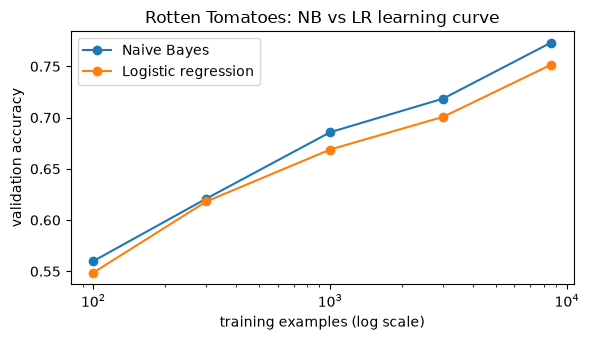

In [30]:
from sklearn.naive_bayes import MultinomialNB

train_sizes = [100, 300, 1000, 3000, len(rt_train_text)]
order = rng.permutation(len(rt_train_text))
curve_rows = []
for size in train_sizes:
    idx = order[:size]
    texts, labels = [rt_train_text[i] for i in idx], rt_train_y[idx]
    nb = make_pipeline(CountVectorizer(ngram_range=(1, 2)), MultinomialNB(alpha=1.0)).fit(texts, labels)
    lr = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True), LogisticRegression(C=4, max_iter=2000)).fit(texts, labels)
    curve_rows.append({"train size": size, "Naive Bayes": nb.score(rt_val_text, rt_val_y), "Logistic regression": lr.score(rt_val_text, rt_val_y)})
curve = pd.DataFrame(curve_rows).set_index("train size")
curve["winner"] = np.where(curve["Naive Bayes"] > curve["Logistic regression"], "Naive Bayes", "Logistic regression")
display(curve.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
curve[["Naive Bayes", "Logistic regression"]].plot(ax=ax, marker="o", logx=True)
ax.set(xlabel="training examples (log scale)", ylabel="validation accuracy", title="Rotten Tomatoes: NB vs LR learning curve")
plt.tight_layout()
plt.show()

In [31]:
nb_small = curve.loc[train_sizes[0], "Naive Bayes"] - curve.loc[train_sizes[0], "Logistic regression"]
nb_full = curve.loc[train_sizes[-1], "Naive Bayes"] - curve.loc[train_sizes[-1], "Logistic regression"]
print(f"NB minus LR accuracy with {train_sizes[0]} examples: {nb_small:+.3f}; with all {train_sizes[-1]:,}: {nb_full:+.3f}")
print("Both are fit in well under a second here — that speed is why they are the first baseline you build.")

NB minus LR accuracy with 100 examples: +0.011; with all 8,530: +0.022
Both are fit in well under a second here — that speed is why they are the first baseline you build.


Both models are **linear**, so they are also **interpretable**: the biggest weights tell you which words drive each class (the mini project prints them). A classic finding from Wang & Manning (2012) is that NB features combined with an SVM or LR are hard to beat on short sentiment snippets.

> 💡 **Interview angle:** "Why does Naive Bayes work for text even though words aren't independent?" — classification only needs the *highest* score to be right, not calibrated probabilities; the independence errors often affect all classes similarly. It is fast, needs little data, and handles many features — but its probabilities are overconfident.

## 12. Word2Vec: Skip-Gram and Negative Sampling 🟡

Bag-of-words treats `car` and `automobile` as unrelated columns. **Word embeddings** give every word a short dense vector (e.g. 100 numbers) where similar words are close together.

The idea is the **distributional hypothesis**: *"You shall know a word by the company it keeps"* (J. R. Firth). Words used in similar contexts have similar meanings.

**Word2vec (skip-gram)** turns that into a prediction game: slide a window over text; for each **center** word, predict the **context** words around it.

```
window = 2:   "the  rocket  [engine]  fired  loudly"
                    ↑        center       ↑
  training pairs: (engine, the) (engine, rocket) (engine, fired) (engine, loudly)
```

Predicting the right word out of 100,000 with a full softmax is expensive. **Negative sampling** replaces it with a cheap binary question: *"is this (center, context) pair real, or a random fake?"* For each real pair, draw $k$ random "negative" words (sampled from the unigram distribution raised to the 0.75 power) and minimize
$$L = -\log \sigma(u_{o}^\top v_c) - \sum_{i=1}^{k} \log \sigma(-u_{i}^\top v_c)$$
where $v_c$ is the center word's vector, $u_o$ the real context word's output vector, $u_i$ the negatives' vectors, and $\sigma$ is the sigmoid. Real pairs get pushed together, fake pairs apart. (**CBOW**, the other word2vec variant, predicts the center word from the average of its context.)

Let's train skip-gram with negative sampling on all 18,846 newsgroup posts (~3.3 million tokens).

In [32]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

news_all = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))
w2v_sentences = [simple_preprocess(doc) for doc in news_all.data]          # lowercase + tokenize + drop 1-char tokens
print(f"{len(w2v_sentences):,} posts, {sum(map(len, w2v_sentences)):,} tokens")

@contextlib.contextmanager
def quiet_gensim_notices():
    """gensim 4.4's compiled training loop occasionally prints to stderr:
    "Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'".
    Its generated C code treats a BLAS dot product of exactly -1.0 as an error signal, prints that line,
    and uses 0 for that single dot product — a handful of updates out of millions, so the vectors are
    effectively unchanged. We capture those lines instead of hiding them silently, and report the count."""
    buffer = io.StringIO()
    with contextlib.redirect_stderr(buffer):
        yield
    notices = buffer.getvalue().count("Exception ignored in")
    other = "\n".join(line for line in buffer.getvalue().splitlines() if "Exception ignored in" not in line and line.strip())
    if notices:
        print(f"(captured {notices} harmless gensim 'Exception ignored' notice(s))")
    if other:
        print("stderr from gensim:\n" + other)                           # anything unexpected is still shown


start = time.perf_counter()
with quiet_gensim_notices():
    w2v = Word2Vec(w2v_sentences, vector_size=100, window=5, min_count=5, sg=1, negative=5, epochs=5, workers=4, seed=SEED)
print(f"trained in {time.perf_counter() - start:.1f}s | vocabulary {len(w2v.wv):,} words | vector size {w2v.wv.vector_size}")
print("(with workers > 1 training is not bit-for-bit reproducible, so neighbours can shift slightly between runs)")

for word in ["car", "hockey", "nasa", "doctor", "gun", "windows"]:
    print(f"{word:8s} → {[w for w, _ in w2v.wv.most_similar(word, topn=6)]}")

18,846 posts, 3,295,264 tokens


(captured 18 harmless gensim 'Exception ignored' notice(s))
trained in 16.1s | vocabulary 26,415 words | vector size 100
(with workers > 1 training is not bit-for-bit reproducible, so neighbours can shift slightly between runs)
car      → ['tires', 'bicycle', 'volvo', 'helmet', 'carb', 'toyota']
hockey   → ['regulars', 'nhl', 'playoff', 'championship', 'standings', 'baseball']
nasa     → ['jpl', 'jsc', 'gov', 'msfc', 'jenks', 'ames']
doctor   → ['she', 'wife', 'ent', 'girlfriend', 'prescription', 'her']
gun      → ['handgun', 'firearms', 'handguns', 'guns', 'defenses', 'ownership']
windows  → ['workgroups', 'dos', 'microsoft', 'excel', 'desktop', 'apps']


From nothing but co-occurrence, the model learned that `hockey` is near `nhl` and `playoff`, and `nasa` near other space agencies and centers. But a few million tokens is small; the famous **analogy** trick (`king - man + woman ≈ queen`) needs far more text. Let's compare with **GloVe** vectors pre-trained on 6 billion tokens of Wikipedia + news. (GloVe is not word2vec — it factorizes a global co-occurrence matrix — but it produces the same kind of vectors.)

In [33]:
import gensim.downloader as gensim_api

print("our 20NG model: king - man + woman →", [w for w, _ in w2v.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3)])

with contextlib.redirect_stdout(io.StringIO()):                            # hide the downloader's progress bar
    glove = gensim_api.load("glove-wiki-gigaword-50")
print(f"GloVe: {len(glove):,} words × {glove.vector_size} dims")

analogies = [("king", "man", "woman"), ("paris", "france", "italy"), ("walking", "walk", "swim")]
for a, b, c in analogies:
    answer = glove.most_similar(positive=[a, c], negative=[b], topn=1)[0]
    print(f"GloVe: {a} - {b} + {c} → {answer[0]} ({answer[1]:.2f})")

our 20NG model: king - man + woman → ['caligiuri', 'solomon', 'herod']


GloVe: 400,000 words × 50 dims
GloVe: king - man + woman → queen (0.85)
GloVe: paris - france + italy → rome (0.85)
GloVe: walking - walk + swim → swimming (0.81)


Now the **limits** of static word vectors — these are what motivated contextual embeddings:

In [34]:
print("1) Antonyms look similar (they share contexts):")
print(f"   sim(good, bad) = {glove.similarity('good', 'bad'):.3f} vs sim(good, great) = {glove.similarity('good', 'great'):.3f}")
print("2) One vector per word, so senses get mixed (polysemy): 'bank' →", [w for w, _ in glove.most_similar("bank", topn=6)])
print("   (river bank? all neighbours are financial)")
print("3) Vectors absorb social biases from the text: doctor - man + woman →",
      [w for w, _ in glove.most_similar(positive=["doctor", "woman"], negative=["man"], topn=3)])
for unseen in ["covid", "chatgpt"]:
    print(f"4) Out-of-vocabulary: is '{unseen}' in our 20NG model? {unseen in w2v.wv.key_to_index}")

1) Antonyms look similar (they share contexts):
   sim(good, bad) = 0.796 vs sim(good, great) = 0.798
2) One vector per word, so senses get mixed (polysemy): 'bank' → ['banks', 'securities', 'banking', 'investment', 'exchange', 'financial']
   (river bank? all neighbours are financial)
3) Vectors absorb social biases from the text: doctor - man + woman → ['nurse', 'child', 'pregnant']
4) Out-of-vocabulary: is 'covid' in our 20NG model? False
4) Out-of-vocabulary: is 'chatgpt' in our 20NG model? False


### ✍️ Your Turn

Compute the cosine similarity between the GloVe vectors for `coffee` and `tea` **yourself** with NumPy (dot product divided by the product of the norms). Store a Python float in `coffee_tea`.

In [35]:
u, v = glove["coffee"], glove["tea"]
coffee_tea = None  # TODO: your code here
check("coffee_tea", coffee_tea, float(glove.similarity("coffee", "tea")), hint="float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))")

⏳ coffee_tea: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
u, v = glove["coffee"], glove["tea"]
coffee_tea = float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))
check("coffee_tea", coffee_tea, float(glove.similarity("coffee", "tea")))
```
</details>

> 💡 **Interview angle:** "Explain negative sampling and why it's needed." — the full softmax over the vocabulary costs O(|V|) per training pair; negative sampling turns it into k+1 binary logistic regressions (k ≈ 5–20), sampling negatives from unigram^0.75 so rare words appear a bit more often. Also mention subsampling of very frequent words.

## 13. FastText: Subword Word Vectors 🟡

**FastText** (Bojanowski et al., 2017) represents a word as the **sum of its character n-gram vectors** (plus a vector for the whole word). Words get boundary markers `<` and `>`, and by default n ranges from 3 to 6.

So a word never seen in training — a typo, a rare inflection — still gets a sensible vector from its pieces. Let's list the *real* n-grams instead of guessing:

In [36]:
from gensim.models import FastText
from gensim.models.fasttext_inner import compute_ngrams

grams = compute_ngrams("unhappiness", 3, 6)
print(f"{len(grams)} character n-grams of '<unhappiness>':", grams)
for piece in ["happy", "happi", "<un", "ness>"]:
    print(f"  is {piece!r} one of them? {piece in grams}")

38 character n-grams of '<unhappiness>': ['<un', 'unh', 'nha', 'hap', 'app', 'ppi', 'pin', 'ine', 'nes', 'ess', 'ss>', '<unh', 'unha', 'nhap', 'happ', 'appi', 'ppin', 'pine', 'ines', 'ness', 'ess>', '<unha', 'unhap', 'nhapp', 'happi', 'appin', 'ppine', 'pines', 'iness', 'ness>', '<unhap', 'unhapp', 'nhappi', 'happin', 'appine', 'ppines', 'piness', 'iness>']
  is 'happy' one of them? False
  is 'happi' one of them? True
  is '<un' one of them? True
  is 'ness>' one of them? True


Note that `happy` is **not** an n-gram of `unhappiness` — the letters are `h-a-p-p-i`, so the shared piece with "happiness" is `happi`. Similarity comes from overlapping pieces like `<un`, `happi`, and `ness>`.

Now train FastText on the six-group training posts and query words it has **never seen**.

In [37]:
ft_sentences = [simple_preprocess(doc) for doc in news_train.data]
start = time.perf_counter()
with quiet_gensim_notices():
    fasttext_model = FastText(ft_sentences, vector_size=100, window=5, min_count=3, sg=1, epochs=5, min_n=3, max_n=6, workers=4, seed=SEED)
    print(f"trained in {time.perf_counter() - start:.1f}s | vocabulary {len(fasttext_model.wv):,}")
    w2v_small = Word2Vec(ft_sentences, vector_size=100, window=5, min_count=3, sg=1, epochs=5, workers=4, seed=SEED)
for query in ["hockeyy", "spacecrafts", "enginess"]:
    in_vocab = query in fasttext_model.wv.key_to_index
    ft_neighbours = [w for w, _ in fasttext_model.wv.most_similar(query, topn=4)]
    try:
        w2v_neighbours = [w for w, _ in w2v_small.wv.most_similar(query, topn=4)]
    except KeyError as err:
        w2v_neighbours = f"KeyError: {err}"
    print(f"{query!r} (in vocab: {in_vocab})\n   FastText → {ft_neighbours}\n   Word2Vec → {w2v_neighbours}")

trained in 7.4s | vocabulary 14,087


(captured 5 harmless gensim 'Exception ignored' notice(s))
'hockeyy' (in vocab: False)
   FastText → ['hockey', 'leagues', 'hoc', 'colleagues']
   Word2Vec → KeyError: "Key 'hockeyy' not present in vocabulary"
'spacecrafts' (in vocab: False)
   FastText → ['spacecraft', 'spacelab', 'spacewalk', 'spacepac']
   Word2Vec → KeyError: "Key 'spacecrafts' not present in vocabulary"
'enginess' (in vocab: False)
   FastText → ['transparent', 'cooperative', 'humane', 'transient']
   Word2Vec → KeyError: "Key 'enginess' not present in vocabulary"


Word2vec simply has no vector for these strings. FastText always returns *something* — read its neighbours critically: shared character pieces often recover the intended word, but spelling overlap is not meaning overlap, so some queries get unrelated neighbours.

### ✍️ Your Turn

Write the FastText-style **character trigrams** (n = 3) of `"where"` **with boundary markers** — slide a window of 3 over `"<where>"`. Store the list in `trigrams`.

In [38]:
word = "where"
trigrams = None  # TODO: your code here
check("trigrams", trigrams, ["<wh", "whe", "her", "ere", "re>"], hint="w = f'<{word}>'; [w[i:i + 3] for i in range(len(w) - 2)]")

⏳ trigrams: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
word = "where"
marked = f"<{word}>"
trigrams = [marked[i:i + 3] for i in range(len(marked) - 2)]
check("trigrams", trigrams, ["<wh", "whe", "her", "ere", "re>"])
```

The markers are why the trigram `her` (inside "where") is a different feature from the whole word `<her>`.
</details>

> 💡 **Interview angle:** "How does FastText handle OOV words?" — it sums the vectors of the word's character n-grams (hashed into a fixed number of buckets), so any string gets a vector. It helps with typos and morphologically rich languages; the cost is a bigger model and neighbours that share spelling but not meaning.

## 14. Topic Modeling with LDA 🔴

**Topic modeling** discovers themes in a collection of documents *without labels*. **LDA** (Latent Dirichlet Allocation, Blei, Ng & Jordan 2003) assumes:

- each **topic** is a probability distribution over words (a "space" topic puts high probability on `orbit`, `launch`, `nasa`);
- each **document** is a mixture of topics (a post can be 70% space, 30% graphics);
- words are generated by picking a topic from the document's mixture, then a word from that topic.

Training works backwards from the words to find topics and mixtures. You must choose **K**, the number of topics. We pick it with **topic coherence** ($C_v$), a score that checks whether a topic's top words tend to appear together in the corpus — it agrees with human judgment better than perplexity does.

LDA works on bag-of-words counts, and here preprocessing *does* matter a lot: stopwords and filler words otherwise dominate every topic.

3,106 posts kept | dictionary size 3,809


swept K in 60s: {4: np.float64(0.459), 5: np.float64(0.661), 6: np.float64(0.613), 7: np.float64(0.578), 8: np.float64(0.563)}
→ best K by C_v coherence: 5 (the true number of newsgroups is 6 — LDA doesn't know that)


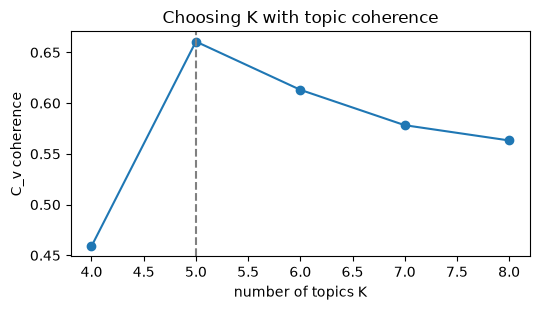

In [39]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel

EXTRA_STOPWORDS = {"would", "could", "also", "one", "get", "like", "know", "think", "say", "said", "use", "used", "go",
                   "well", "may", "much", "even", "make", "see", "way", "thing", "really", "want", "need", "good", "time",
                   "year", "people", "edu", "com", "new", "first", "two", "anyone", "something", "take", "many", "still",
                   "right", "back", "look", "going", "got"}
LDA_STOPWORDS = NLTK_STOPWORDS | EXTRA_STOPWORDS


def lda_tokens(doc):
    lemmas = (wordnet_lemmatizer.lemmatize(tok) for tok in simple_preprocess(doc, min_len=3) if tok not in LDA_STOPWORDS)
    return [lem for lem in lemmas if lem not in LDA_STOPWORDS]


lda_docs, lda_labels = [], []
for doc, label in zip(news_train.data, news_train.target):
    toks = lda_tokens(doc)
    if len(toks) >= 10:                                                  # very short posts give LDA almost no signal
        lda_docs.append(toks)
        lda_labels.append(news_train.target_names[label])
dictionary = Dictionary(lda_docs)
dictionary.filter_extremes(no_below=10, no_above=0.2)                  # drop rare words and words in >20% of posts
bow_corpus = [dictionary.doc2bow(toks) for toks in lda_docs]
print(f"{len(lda_docs):,} posts kept | dictionary size {len(dictionary):,}")

coherence_by_k, models_by_k = {}, {}
start = time.perf_counter()
for k in [4, 5, 6, 7, 8]:
    lda = LdaModel(bow_corpus, num_topics=k, id2word=dictionary, passes=8, iterations=100,
                   alpha="auto", eta="auto", chunksize=2000, random_state=SEED)
    coherence_by_k[k] = CoherenceModel(model=lda, texts=lda_docs, dictionary=dictionary, coherence="c_v", processes=1).get_coherence()
    models_by_k[k] = lda
print(f"swept K in {time.perf_counter() - start:.0f}s:", {k: round(c, 3) for k, c in coherence_by_k.items()})

best_k = max(coherence_by_k, key=coherence_by_k.get)
best_lda = models_by_k[best_k]
print(f"→ best K by C_v coherence: {best_k} (the true number of newsgroups is {len(CATEGORIES)} — LDA doesn't know that)")

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(list(coherence_by_k), list(coherence_by_k.values()), marker="o")
ax.axvline(best_k, ls="--", color="gray")
ax.set(xlabel="number of topics K", ylabel="C_v coherence", title="Choosing K with topic coherence")
plt.tight_layout()
plt.show()

Topic numbers are arbitrary — topic 0 in one run can be topic 3 in the next. So we **never hard-code topic names**; we label each topic from its own top words, and check what it captured by comparing each post's dominant topic with its (hidden-from-LDA) newsgroup.

In [40]:
topic_labels = {t: " / ".join(w for w, _ in best_lda.show_topic(t, topn=3)) for t in range(best_k)}
dominant = [max(best_lda.get_document_topics(bow, minimum_probability=0.0), key=lambda pair: pair[1])[0] for bow in bow_corpus]
alignment = pd.crosstab(pd.Series([topic_labels[t] for t in dominant], name="dominant topic"),
                        pd.Series(lda_labels, name="true newsgroup"), normalize="index")

summary_rows = []
for t in range(best_k):
    row = alignment.loc[topic_labels[t]]
    summary_rows.append({"topic (auto-label)": topic_labels[t],
                         "top 8 words": ", ".join(w for w, _ in best_lda.show_topic(t, topn=8)),
                         "posts": dominant.count(t), "best-matching newsgroup": row.idxmax(), "share": row.max()})
topic_summary = pd.DataFrame(summary_rows).sort_values("share", ascending=False)
display(topic_summary.round(2))
clean_topics = int((topic_summary["share"] >= 0.7).sum())
print(f"{clean_topics} of {best_k} topics have ≥70% of their posts from a single newsgroup; "
      f"{best_k - clean_topics} topic(s) mix several newsgroups.")

,topic (auto-label),top 8 words,posts,best-matching newsgroup,share
4,game / team / hockey,"game, team, hockey, play, season, player, nhl, goal",477,rec.sport.hockey,0.97
2,space / nasa / mission,"space, nasa, mission, satellite, system, earth, launch, orbit",307,sci.space,0.84
1,patient / health / disease,"patient, health, disease, food, problem, medical, doctor, study",495,sci.med,0.77
3,image / file / graphic,"image, file, graphic, program, software, data, available, format",568,comp.graphics,0.76
0,gun / car / weapon,"gun, car, weapon, law, firearm, state, problem, point",1259,rec.autos,0.36


4 of 5 topics have ≥70% of their posts from a single newsgroup; 1 topic(s) mix several newsgroups.


LDA recovered several real themes with zero labels, and also produced mixed topics — that's normal. Coherence differences between neighbouring K values are often small, so treat K as a judgment call guided by the score and by whether the topics are useful.

**Modern alternative — embedding-based topic models.** [BERTopic](https://maartengr.github.io/BERTopic/) embeds each document with a sentence transformer, reduces dimensions (UMAP), clusters (HDBSCAN), then describes each cluster with class-based TF-IDF. It captures meaning beyond shared words and works on short texts where LDA struggles, at the cost of GPU/CPU time for embeddings. You will build the embedding half of that in the next notebook.

> 💡 **Interview angle:** "How do you choose the number of topics?" — sweep K, score coherence (C_v or NPMI) on the corpus, and inspect topics by hand; perplexity often keeps improving with K while topics get worse for humans. Also: topic IDs are not stable across runs, so label from top words.

## 15. When Classical NLP Still Wins 🟢

Let's settle "why not just use a transformer?" with numbers instead of opinions. We compare, on a validation split of the newsgroup training data:

- **TF-IDF + logistic regression**, and
- **sentence embeddings** from `all-MiniLM-L6-v2` (a small 22M-parameter transformer) + logistic regression.

We measure accuracy, training time, model size, and **latency for one document at a time** (how a web API receives requests).

In [41]:
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

nonempty = [(d, y) for d, y in zip(news_train.data, news_train.target) if d.strip()]
docs15, y15 = [d for d, _ in nonempty], np.array([y for _, y in nonempty])
X_tr15, X_val15, y_tr15, y_val15 = train_test_split(docs15, y15, test_size=0.2, stratify=y15, random_state=SEED)

tfidf_lr = make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), LogisticRegression(C=10, max_iter=2000))
_, tfidf_fit_s = time_it(lambda: tfidf_lr.fit(X_tr15, y_tr15))
tfidf_f1 = f1_score(y_val15, tfidf_lr.predict(X_val15), average="macro")
tfidf_mb = len(pickle.dumps(tfidf_lr)) / 1e6

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
emb_tr, encode_s = time_it(lambda: encoder.encode(X_tr15, batch_size=64, normalize_embeddings=True))
emb_val = encoder.encode(X_val15, batch_size=64, normalize_embeddings=True)
emb_lr = LogisticRegression(C=10, max_iter=2000)
_, emb_head_s = time_it(lambda: emb_lr.fit(emb_tr, y_tr15))
emb_f1 = f1_score(y_val15, emb_lr.predict(emb_val), average="macro")
emb_mb = sum(p.numel() * p.element_size() for p in encoder.parameters()) / 1e6 + len(pickle.dumps(emb_lr)) / 1e6

one_at_a_time = X_val15[:100]
_, tfidf_lat = time_it(lambda: [tfidf_lr.predict([d]) for d in one_at_a_time])
_, emb_lat = time_it(lambda: [emb_lr.predict(encoder.encode([d])) for d in one_at_a_time])

comparison = pd.DataFrame({
    "val macro-F1": [tfidf_f1, emb_f1],
    "train time (s)": [tfidf_fit_s, encode_s + emb_head_s],
    "model size (MB)": [tfidf_mb, emb_mb],
    "latency per doc (ms)": [tfidf_lat / len(one_at_a_time) * 1000, emb_lat / len(one_at_a_time) * 1000],
}, index=["TF-IDF + LR (CPU)", f"MiniLM embeddings + LR ({device})"])
display(comparison.round(3))

speedup = comparison["latency per doc (ms)"].iloc[1] / comparison["latency per doc (ms)"].iloc[0]
f1_gap = emb_f1 - tfidf_f1
better = "embeddings" if f1_gap > 0 else "TF-IDF"
print(f"TF-IDF + LR is {speedup:.0f}× faster per document and {emb_mb / tfidf_mb:.0f}× smaller; "
      f"{better} scores higher by {abs(f1_gap):.3f} macro-F1 on this split.")
del encoder, emb_tr, emb_val
if device == "mps":
    torch.mps.empty_cache()

,val macro-F1,train time (s),model size (MB),latency per doc (ms)
TF-IDF + LR (CPU),0.899,1.256,1.129,1.132
MiniLM embeddings + LR (mps),0.915,7.092,90.863,19.695


TF-IDF + LR is 17× faster per document and 80× smaller; embeddings scores higher by 0.017 macro-F1 on this split.


Your exact numbers depend on hardware, but the pattern is typical. Classical NLP still wins when:

| Situation | Why classical wins |
|---|---|
| **Tight latency / high volume** (spam filters, routing millions of messages) | sub-millisecond CPU inference, no GPU |
| **Cost** | no per-token API bill; runs on the smallest instance |
| **Interpretability / regulation** | every weight maps to a word you can show an auditor |
| **Tiny labeled data** | NB needs very few examples (section 11) |
| **Exact-term matching** | product codes, error IDs, names — BM25/TF-IDF match exact tokens embeddings may blur |
| **Edge / offline** | a few MB, no internet |

And the transformer side wins on meaning (synonyms, paraphrases), context, multilingual text, and zero-shot tasks with no labels. In practice teams **combine** them: a cheap classifier or BM25 first, an embedding model or LLM for the hard cases.

> 💡 **Interview angle:** "Would you use an LLM for this classification task?" — start with a TF-IDF + LR baseline in an hour, measure it, then compare an embedding model or LLM on quality **and** latency, cost per 1k requests, and maintenance. Choose the cheapest model that meets the target.

## 🔧 Build It From Scratch

Interviewers love "implement TF-IDF" and "implement Naive Bayes". We build both with only Python and NumPy, then `assert` they match scikit-learn exactly.

### 1) Tokenizer + TF-IDF vectorizer

To match `TfidfVectorizer()` defaults we need: lowercase, token pattern `(?u)\b\w\w+\b`, vocabulary sorted alphabetically, smoothed IDF $\ln\frac{1+n}{1+\text{df}} + 1$, raw counts as TF, and L2-normalized rows.

In [42]:
class ScratchTfidf:
    token_pattern = re.compile(r"(?u)\b\w\w+\b")

    def tokenize(self, doc):
        return self.token_pattern.findall(doc.lower())

    def fit(self, docs):
        tokenized = [self.tokenize(d) for d in docs]
        self.vocabulary_ = {term: i for i, term in enumerate(sorted({t for toks in tokenized for t in toks}))}
        df = np.zeros(len(self.vocabulary_))
        for toks in tokenized:
            for term in set(toks):                                     # document frequency counts each doc once
                df[self.vocabulary_[term]] += 1
        n = len(docs)
        self.idf_ = np.log((1 + n) / (1 + df)) + 1
        return self

    def transform(self, docs):
        X = np.zeros((len(docs), len(self.vocabulary_)))
        for row, doc in enumerate(docs):
            for term, count in Counter(self.tokenize(doc)).items():
                if term in self.vocabulary_:                          # unseen test words are ignored
                    X[row, self.vocabulary_[term]] = count
        X *= self.idf_
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        return X / np.where(norms == 0, 1, norms)                     # empty docs stay all-zero


fit_docs, new_docs = news_train.data[:600], news_test.data[:200]
ours = ScratchTfidf().fit(fit_docs)
reference = TfidfVectorizer().fit(fit_docs)

assert list(ours.vocabulary_) == list(reference.get_feature_names_out())
assert np.allclose(ours.idf_, reference.idf_)
assert np.allclose(ours.transform(new_docs), reference.transform(new_docs).toarray())
print(f"✅ ScratchTfidf matches TfidfVectorizer: vocabulary {len(ours.vocabulary_):,} terms, "
      f"IDF and a {len(new_docs)}×{len(ours.vocabulary_):,} test matrix identical")

✅ ScratchTfidf matches TfidfVectorizer: vocabulary 14,361 terms, IDF and a 200×14,361 test matrix identical


### 2) Multinomial Naive Bayes

Training = counting words per class. Prediction = add log-probabilities, then normalize with log-sum-exp (never multiply thousands of tiny probabilities — they underflow to 0).

In [43]:
class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.classes_ = np.unique(y)
        class_counts = np.array([(y == c).sum() for c in self.classes_])
        self.class_log_prior_ = np.log(class_counts / class_counts.sum())
        word_counts = np.stack([X[y == c].sum(axis=0) for c in self.classes_]) + self.alpha   # (classes, vocab)
        self.feature_log_prob_ = np.log(word_counts / word_counts.sum(axis=1, keepdims=True))
        return self

    def predict_log_proba(self, X):
        joint = np.asarray(X, dtype=float) @ self.feature_log_prob_.T + self.class_log_prior_  # (docs, classes)
        top = joint.max(axis=1, keepdims=True)
        log_norm = top + np.log(np.exp(joint - top).sum(axis=1, keepdims=True))            # stable log-sum-exp
        return joint - log_norm

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(axis=1)]


counter = CountVectorizer(min_df=2).fit(news_train.data)
X_counts_train = counter.transform(news_train.data).toarray()
X_counts_test = counter.transform(news_test.data[:500]).toarray()

scratch_nb = ScratchMultinomialNB(alpha=1.0).fit(X_counts_train, news_train.target)
sk_nb = MultinomialNB(alpha=1.0).fit(X_counts_train, news_train.target)

assert np.allclose(scratch_nb.class_log_prior_, sk_nb.class_log_prior_)
assert np.allclose(scratch_nb.feature_log_prob_, sk_nb.feature_log_prob_)
assert np.allclose(np.exp(scratch_nb.predict_log_proba(X_counts_test)), sk_nb.predict_proba(X_counts_test))
assert (scratch_nb.predict(X_counts_test) == sk_nb.predict(X_counts_test)).all()
print(f"✅ ScratchMultinomialNB matches sklearn on {X_counts_test.shape[0]} test posts × {X_counts_test.shape[1]:,} features "
      f"(accuracy {(scratch_nb.predict(X_counts_test) == news_test.target[:500]).mean():.3f})")
del X_counts_train, X_counts_test

✅ ScratchMultinomialNB matches sklearn on 500 test posts × 18,588 features (accuracy 0.846)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Leaving label-revealing metadata in the text

Newsgroup headers literally contain the group name, and signatures repeat per author. A model trained on raw posts looks brilliant in validation and fails on text without that metadata. We compare on a validation split of the training data.

In [44]:
raw_train = fetch_20newsgroups(subset="train", categories=CATEGORIES, random_state=SEED)                 # ❌ headers kept
print("a raw post starts with:", raw_train.data[0][:160].replace("\n", " | "))
clean_by_filename = dict(zip(news_train.filenames, news_train.data))
clean_docs = [clean_by_filename[f] for f in raw_train.filenames]                                          # ✅ same posts, cleaned
tr_idx, val_idx = train_test_split(np.arange(len(raw_train.data)), test_size=0.25, stratify=raw_train.target, random_state=SEED)

for name, corpus in [("❌ with headers/footers/quotes", raw_train.data), ("✅ body text only", clean_docs)]:
    model = make_pipeline(TfidfVectorizer(sublinear_tf=True), LogisticRegression(C=10, max_iter=2000))
    model.fit([corpus[i] for i in tr_idx], raw_train.target[tr_idx])
    print(f"{name:32s} validation accuracy: {model.score([corpus[i] for i in val_idx], raw_train.target[val_idx]):.3f}")
print("The first number is inflated by leakage — the 'real' task is the second.")

a raw post starts with: From: MAILRP%ESA.BITNET@vm.gmd.de | Subject: message from Space Digest | X-Added: Forwarded by Space Digest | Organization: [via International Space University] | Origi


❌ with headers/footers/quotes    validation accuracy: 0.973


✅ body text only                 validation accuracy: 0.883
The first number is inflated by leakage — the 'real' task is the second.


### ❌ Pitfall 2 — Calling `fit_transform` on the test set

In [45]:
vec = TfidfVectorizer()
clf = LogisticRegression(max_iter=1000).fit(vec.fit_transform(X_tr15), y_tr15)
try:
    clf.predict(TfidfVectorizer().fit_transform(X_val15))                  # ❌ new vocabulary, different columns
except ValueError as err:
    print("❌", err)
print(f"✅ transform with the fitted vectorizer → accuracy {clf.score(vec.transform(X_val15), y_val15):.3f}")

❌ X has 14905 features, but LogisticRegression is expecting 37090 features as input.
✅ transform with the fitted vectorizer → accuracy 0.877


Even when the shapes happen to match (e.g. `max_features=1000` on both), column 17 would mean a *different word* in each matrix — a silent garbage result. Wrap the vectorizer and model in one `Pipeline` so this cannot happen.

### ❌ Pitfall 3 — Lemmatizing without a part of speech

In [46]:
tokens = ["was", "running", "better", "leaves"]
print("❌ default (noun):", [wordnet_lemmatizer.lemmatize(t) for t in tokens])
doc3 = nlp("She was running better than the leaves were falling.")
print("✅ spaCy (uses POS):", [(t.text, t.lemma_) for t in doc3 if t.text in {"was", "running", "better", "leaves"}])

❌ default (noun): ['wa', 'running', 'better', 'leaf']
✅ spaCy (uses POS): [('was', 'be'), ('running', 'run'), ('better', 'well'), ('leaves', 'leaf')]


### ❌ Pitfall 4 — Loading the spaCy model inside a loop

In [47]:
few_docs = docs_for_timing[:20]


def entities_slow(texts):
    return [[e.text for e in spacy.load("en_core_web_sm")(t).ents] for t in texts]     # ❌ reloads the model every time


def entities_fast(texts):
    with nlp.select_pipes(enable=["ner"]):
        return [[e.text for e in d.ents] for d in nlp.pipe(texts)]                # ✅ load once, stream, only NER


slow, t_slow = time_it(lambda: entities_slow(few_docs))
fast, t_fast = time_it(lambda: entities_fast(few_docs))
print(f"❌ load per doc: {t_slow:.2f}s | ✅ load once + pipe: {t_fast:.2f}s → {t_slow / t_fast:.0f}× faster, same result: {slow == fast}")

❌ load per doc: 8.91s | ✅ load once + pipe: 0.31s → 29× faster, same result: True


### ❌ Pitfall 5 — Assuming every word has a word2vec vector

In [48]:
try:
    w2v.wv["covid"]                                                          # ❌ KeyError for OOV words
except KeyError as err:
    print("❌ KeyError:", err)

query_words = ["covid", "vaccine", "orbit"]
known = [w for w in query_words if w in w2v.wv.key_to_index]                 # ✅ check (or use FastText)
print("✅ known words:", known, "| skipped:", sorted(set(query_words) - set(known)))

❌ KeyError: "Key 'covid' not present"
✅ known words: ['vaccine', 'orbit'] | skipped: ['covid']


### ❌ Pitfall 6 — Hard-coding LDA topic names

In [49]:
lda_seed_a = LdaModel(bow_corpus, num_topics=best_k, id2word=dictionary, passes=4, random_state=1)
lda_seed_b = LdaModel(bow_corpus, num_topics=best_k, id2word=dictionary, passes=4, random_state=2)
print("❌ 'topic 0' under two random seeds:")
print("   seed 1:", [w for w, _ in lda_seed_a.show_topic(0, topn=5)])
print("   seed 2:", [w for w, _ in lda_seed_b.show_topic(0, topn=5)])
print("✅ label from each model's own top words instead:",
      {t: "/".join(w for w, _ in lda_seed_b.show_topic(t, topn=2)) for t in range(best_k)})

❌ 'topic 0' under two random seeds:
   seed 1: ['game', 'team', 'hockey', 'player', 'season']
   seed 2: ['car', 'gun', 'point', 'problem', 'weapon']
✅ label from each model's own top words instead: {0: 'car/gun', 1: 'space/mission', 2: 'image/file', 3: 'patient/study', 4: 'game/team'}


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count sentences
Use NLTK's `sent_tokenize` to count the sentences in `paragraph`. Store an integer in `n_sentences`.

In [50]:
paragraph = "Transformers changed NLP. But TF-IDF still matters! Why? It is fast, cheap, and easy to explain."
n_sentences = None  # TODO
check("n_sentences", n_sentences, 4, hint="len(sent_tokenize(paragraph))")

⏳ n_sentences: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
paragraph = "Transformers changed NLP. But TF-IDF still matters! Why? It is fast, cheap, and easy to explain."
n_sentences = len(sent_tokenize(paragraph))
check("n_sentences", n_sentences, 4)
```
</details>

### 🟢 Exercise 2 — Remove stopwords, keep negations
Remove NLTK stopwords from `review_tokens`, **except** `"not"`, `"no"`, and `"nor"`. Keep the original order.

In [51]:
review_tokens = ["this", "phone", "is", "not", "worth", "the", "money", "and", "it", "has", "no", "charger"]
kept = None  # TODO
check("kept", kept, ["phone", "not", "worth", "money", "no", "charger"],
      hint="Keep a token if it is not in NLTK_STOPWORDS or it is in {'not', 'no', 'nor'}.")

⏳ kept: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
review_tokens = ["this", "phone", "is", "not", "worth", "the", "money", "and", "it", "has", "no", "charger"]
keep_anyway = {"not", "no", "nor"}
kept = [t for t in review_tokens if t not in NLTK_STOPWORDS or t in keep_anyway]
check("kept", kept, ["phone", "not", "worth", "money", "no", "charger"])
```
</details>

### 🟢 Exercise 3 — Bigrams
Return all bigrams (pairs of consecutive tokens) of `tokens3` as a list of tuples.

In [52]:
tokens3 = ["new", "york", "is", "not", "new", "jersey"]
bigrams = None  # TODO
check("bigrams", bigrams, [("new", "york"), ("york", "is"), ("is", "not"), ("not", "new"), ("new", "jersey")],
      hint="zip a list with itself shifted by one: zip(tokens3, tokens3[1:])")

⏳ bigrams: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tokens3 = ["new", "york", "is", "not", "new", "jersey"]
bigrams = list(zip(tokens3, tokens3[1:]))
check("bigrams", bigrams, [("new", "york"), ("york", "is"), ("is", "not"), ("not", "new"), ("new", "jersey")])
```
`nltk.bigrams(tokens3)` does the same thing.
</details>

### 🟡 Exercise 4 — The most distinctive word per document
Fit `TfidfVectorizer(stop_words="english")` on `docs4`. For each document, return the vocabulary term with the **highest TF-IDF weight**, as a list of 4 strings.

In [53]:
docs4 = ["engine oil leak: the engine overheated and the engine stalled on the highway",
         "the goalie blocked the shot, then the goalie saved the game",
         "the rocket engine fired and the rocket reached orbit",
         "the nurse checked the patient and the patient slept"]
top_terms = None  # TODO
check("top_terms", top_terms, ["engine", "goalie", "rocket", "patient"],
      hint="X = vec.fit_transform(docs4); names = vec.get_feature_names_out(); argmax of each row of X.toarray().")

⏳ top_terms: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
docs4 = ["engine oil leak: the engine overheated and the engine stalled on the highway",
         "the goalie blocked the shot, then the goalie saved the game",
         "the rocket engine fired and the rocket reached orbit",
         "the nurse checked the patient and the patient slept"]
vec4 = TfidfVectorizer(stop_words="english")
X4 = vec4.fit_transform(docs4).toarray()
names4 = vec4.get_feature_names_out()
top_terms = [str(names4[i]) for i in X4.argmax(axis=1)]
check("top_terms", top_terms, ["engine", "goalie", "rocket", "patient"])
```
`engine` appears in two documents (lower IDF) but three times in the first, so TF wins there.
</details>

### 🟡 Exercise 5 — Subject–verb–object triples
For each sentence in `svo_doc.sents`, find the `ROOT` verb and return `(subject.text, root.lemma_, object.text)`, where the subject is a child with dep `nsubj` or `nsubjpass`, and the object is the child with dep `dobj` — or, if there is no `dobj`, the `pobj` under an `agent` or `prep` child of the root.

In [54]:
svo_doc = nlp("The committee approved the new budget. The probe was launched by NASA. Engineers in Houston tracked the probe.")


def extract_svo(sentence):
    return None  # TODO: return one (subject, verb_lemma, object) tuple


triples = None  # TODO: [extract_svo(s) for s in svo_doc.sents]
check("triples", triples, [("committee", "approve", "budget"), ("probe", "launch", "NASA"), ("Engineers", "track", "probe")],
      hint="pobj is a child of the preposition, not of the verb. Houston hangs off 'Engineers', so it must not be picked.")

⏳ triples: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
svo_doc = nlp("The committee approved the new budget. The probe was launched by NASA. Engineers in Houston tracked the probe.")

def extract_svo(sentence):
    root = sentence.root
    subject = next(c for c in root.children if c.dep_ in ("nsubj", "nsubjpass"))
    obj = next((c for c in root.children if c.dep_ == "dobj"), None)
    if obj is None:
        obj = next(g for c in root.children if c.dep_ in ("agent", "prep") for g in c.children if g.dep_ == "pobj")
    return (subject.text, root.lemma_, obj.text)

triples = [extract_svo(s) for s in svo_doc.sents]
check("triples", triples, [("committee", "approve", "budget"), ("probe", "launch", "NASA"), ("Engineers", "track", "probe")])
```
Real extractors also handle conjunctions ("approved and signed"), clausal objects, and negation — which is why many teams now pair a parser with an LLM for messy text.
</details>

### 🔴 Exercise 6 — Skip-gram negative-sampling loss and gradient (interview classic)
Implement one SGNS step in NumPy. Given the center vector `v_c`, the true context output vector `u_o`, and negative output vectors `U_neg` (one per row), return a tuple `(loss, grad_v_c)`:

$$L = -\log\sigma(u_o^\top v_c) - \sum_k \log\sigma(-u_k^\top v_c), \qquad \frac{\partial L}{\partial v_c} = (\sigma(u_o^\top v_c) - 1)\,u_o + \sum_k \sigma(u_k^\top v_c)\,u_k$$

In [55]:
v_c = np.array([0.2, -0.1, 0.4])
u_o = np.array([0.3, 0.5, -0.2])
U_neg = np.array([[0.1, 0.2, 0.3],
                  [-0.4, 0.1, 0.0]])


def sgns_loss_and_grad(v_c, u_o, U_neg):
    return None  # TODO: return (loss, grad_v_c)


result = sgns_loss_and_grad(v_c, u_o, U_neg)
check("sgns", None if result is None else np.r_[result[0], result[1]],
      [2.132864996169921, -0.2932575196, -0.1050021003, 0.2624877868],
      hint="sigmoid = lambda x: 1 / (1 + np.exp(-x)); negatives: U_neg @ v_c has shape (k,).")

⏳ sgns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v_c = np.array([0.2, -0.1, 0.4])
u_o = np.array([0.3, 0.5, -0.2])
U_neg = np.array([[0.1, 0.2, 0.3], [-0.4, 0.1, 0.0]])

def sgns_loss_and_grad(v_c, u_o, U_neg):
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    pos_score = u_o @ v_c                      # scalar
    neg_scores = U_neg @ v_c                   # (k,)
    loss = -np.log(sigmoid(pos_score)) - np.log(sigmoid(-neg_scores)).sum()
    grad_v_c = (sigmoid(pos_score) - 1) * u_o + (sigmoid(neg_scores)[:, None] * U_neg).sum(axis=0)
    return loss, grad_v_c

result = sgns_loss_and_grad(v_c, u_o, U_neg)
check("sgns", np.r_[result[0], result[1]], [2.132864996169921, -0.2932575196, -0.1050021003, 0.2624877868])

# Verify the gradient numerically (finite differences) — always do this in an interview if you can
eps = 1e-6
numeric = [(sgns_loss_and_grad(v_c + eps * e, u_o, U_neg)[0] - sgns_loss_and_grad(v_c - eps * e, u_o, U_neg)[0]) / (2 * eps) for e in np.eye(3)]
check("sgns gradient (finite differences)", numeric, [-0.2932575196, -0.1050021003, 0.2624877868])
```
Use $\frac{d}{dx}\log\sigma(x) = 1 - \sigma(x)$ and $\sigma(-x) = 1 - \sigma(x)$. For numerical stability in real code use `np.logaddexp(0, -x)` for $-\log\sigma(x)$.
</details>

## 🚀 Mini Project: Newsgroup Classifier and Entity Extractor

**Goal:** build and justify a text classifier for six real newsgroups, understand its mistakes, and extract named entities from the posts — the kind of first system you'd build for routing support tickets or tagging documents.

**Steps:** clean data → choose a model with cross-validation on the training set only → evaluate once on the official test set (posts written later in time) → error analysis → top features per class → entity extraction → computed conclusions.

### Step 1 — Load and clean

In [56]:
def drop_empty(bunch):
    keep = [i for i, d in enumerate(bunch.data) if len(d.split()) >= 3]      # posts with < 3 words carry no signal
    return [bunch.data[i] for i in keep], bunch.target[keep]


proj_X_train, proj_y_train = drop_empty(news_train)
proj_X_test, proj_y_test = drop_empty(news_test)
names = news_train.target_names
print(f"train {len(proj_X_train):,} (dropped {len(news_train.data) - len(proj_X_train)}) | "
      f"test {len(proj_X_test):,} (dropped {len(news_test.data) - len(proj_X_test)})")
print("test class balance:", dict(zip(names, np.bincount(proj_y_test).tolist())))

train 3,389 (dropped 122) | test 2,251 (dropped 87)
test class balance: {'comp.graphics': 384, 'rec.autos': 369, 'rec.sport.hockey': 389, 'sci.med': 381, 'sci.space': 376, 'talk.politics.guns': 352}


### Step 2 — Model selection with 5-fold cross-validation (training data only)

Each candidate is a full `Pipeline`, so the vectorizer is re-fit inside every fold — no leakage from validation folds. We use **macro-F1** (the average F1 over classes) so every class counts equally.

In [57]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
candidates = {
    "Naive Bayes (counts)": (make_pipeline(CountVectorizer(min_df=2), MultinomialNB()),
                             {"multinomialnb__alpha": [0.01, 0.1, 0.5, 1.0]}),
    "Naive Bayes (TF-IDF)": (make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), MultinomialNB()),
                             {"multinomialnb__alpha": [0.01, 0.05, 0.2]}),
    "Logistic regression (TF-IDF)": (make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), LogisticRegression(max_iter=3000)),
                                     {"logisticregression__C": [3, 10, 30]}),
}
searches, cv_rows = {}, []
for name, (pipe, grid) in candidates.items():
    search = GridSearchCV(pipe, grid, cv=cv, scoring="f1_macro", n_jobs=4)
    _, seconds = time_it(lambda: search.fit(proj_X_train, proj_y_train))
    searches[name] = search
    best = search.cv_results_["rank_test_score"].argmin()
    cv_rows.append({"model": name, "CV macro-F1": search.best_score_, "± std": search.cv_results_["std_test_score"][best],
                    "best params": search.best_params_, "search time (s)": seconds})
cv_table = pd.DataFrame(cv_rows).set_index("model").sort_values("CV macro-F1", ascending=False)
cv_table.round(4)

,CV macro-F1,± std,best params,search time (s)
model,,,,
Naive Bayes (TF-IDF),0.9100,0.0121,{'multinomialnb__alpha': 0.05},2.2185
Logistic regression (TF-IDF),0.9010,0.0111,{'logisticregression__C': 3},6.1288
Naive Bayes (counts),0.8917,0.0148,{'multinomialnb__alpha': 0.01},7.5543


In [58]:
winner_name = cv_table.index[0]
runner_up = cv_table.index[1]
margin = cv_table.loc[winner_name, "CV macro-F1"] - cv_table.loc[runner_up, "CV macro-F1"]
within_noise = margin < cv_table.loc[winner_name, "± std"]
winner = searches[winner_name].best_estimator_                                  # refit on all training data
print(f"Selected: {winner_name} (CV macro-F1 {cv_table.loc[winner_name, 'CV macro-F1']:.3f}), "
      f"ahead of {runner_up} by {margin:.3f}" + (" — smaller than one fold std, so practically a tie." if within_noise else "."))

Selected: Naive Bayes (TF-IDF) (CV macro-F1 0.910), ahead of Logistic regression (TF-IDF) by 0.009 — smaller than one fold std, so practically a tie.


### Step 3 — Evaluate once on the test set

TEST accuracy 0.896 | macro-F1 0.896 (CV estimate was 0.910)
                    precision    recall  f1-score   support

     comp.graphics      0.903     0.924     0.914       384
         rec.autos      0.883     0.902     0.893       369
  rec.sport.hockey      0.966     0.938     0.952       389
           sci.med      0.925     0.843     0.882       381
         sci.space      0.880     0.859     0.869       376
talk.politics.guns      0.823     0.909     0.864       352

          accuracy                          0.896      2251
         macro avg      0.897     0.896     0.896      2251
      weighted avg      0.898     0.896     0.896      2251



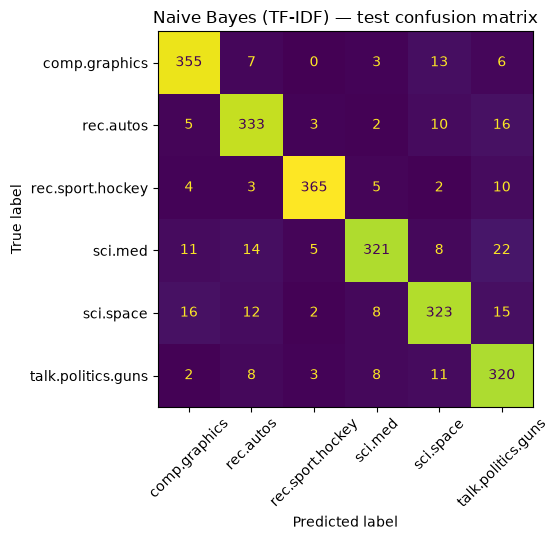

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix

test_pred = winner.predict(proj_X_test)
test_proba = winner.predict_proba(proj_X_test)
test_f1 = f1_score(proj_y_test, test_pred, average="macro")
print(f"TEST accuracy {accuracy_score(proj_y_test, test_pred):.3f} | macro-F1 {test_f1:.3f} "
      f"(CV estimate was {cv_table.loc[winner_name, 'CV macro-F1']:.3f})")
print(classification_report(proj_y_test, test_pred, target_names=names, digits=3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(proj_y_test, test_pred, display_labels=names, xticks_rotation=45, ax=ax, colorbar=False)
ax.set_title(f"{winner_name} — test confusion matrix")
plt.tight_layout()
plt.show()

### Step 4 — Error analysis

Numbers tell you *how much* the model is wrong; reading errors tells you *why*.

In [60]:
cm = confusion_matrix(proj_y_test, test_pred)
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
true_i, pred_i = np.unravel_index(off_diag.argmax(), off_diag.shape)
print(f"most common confusion: {names[true_i]} → predicted as {names[pred_i]} ({off_diag[true_i, pred_i]} posts)")

test_len = np.array([len(d.split()) for d in proj_X_test])
wrong = test_pred != proj_y_test
print(f"median length of misclassified posts: {np.median(test_len[wrong]):.0f} words vs correct: {np.median(test_len[~wrong]):.0f}")
short = test_len < 30
print(f"error rate on posts < 30 words: {wrong[short].mean():.1%} vs ≥ 30 words: {wrong[~short].mean():.1%}")

confidence = test_proba.max(axis=1)
errors = pd.DataFrame({"true": [names[i] for i in proj_y_test[wrong]], "predicted": [names[i] for i in test_pred[wrong]],
                       "confidence": confidence[wrong], "words": test_len[wrong],
                       "text": [" ".join(d.split())[:160] for d, w in zip(proj_X_test, wrong) if w]})
print("\nMost confident mistakes:")
errors.sort_values("confidence", ascending=False).head(6).round(2)

most common confusion: sci.med → predicted as talk.politics.guns (22 posts)
median length of misclassified posts: 44 words vs correct: 90
error rate on posts < 30 words: 26.6% vs ≥ 30 words: 7.4%

Most confident mistakes:


,true,predicted,confidence,words,text
190,comp.graphics,sci.space,0.99,1665,Invitation to the 8th SCIA The 8th Scandinavian Conference on Image Analysis...
80,sci.space,comp.graphics,0.99,140,I commend everybody to look at the FTP site 'ftp.cicb.fr' -> Ethernet addres...
86,sci.space,talk.politics.guns,0.99,130,We don't disagree on this. All I said was that a right is whatever you or so...
174,sci.med,talk.politics.guns,0.98,780,"Here is a press release from the American Federation of State, County and Mu..."
68,sci.space,comp.graphics,0.98,127,The compressed image format used for the Voyager disks is not (yet) supporte...
35,sci.space,comp.graphics,0.98,265,"-| In article <1993Apr28.200843.83413@embl-heidelberg.de>, tuparev@EMBL-Heid..."


### Step 5 — What did the model learn? Top features per class

In [61]:
final_step = winner[-1]
feature_names = winner[0].get_feature_names_out()
if hasattr(final_step, "coef_"):                                            # logistic regression: one weight per class × word
    class_scores = final_step.coef_
    score_kind = "LR coefficient"
else:                                                                       # Naive Bayes: log P(word|class) minus the average over classes
    class_scores = final_step.feature_log_prob_ - final_step.feature_log_prob_.mean(axis=0)
    score_kind = "log-prob ratio"
top_features = pd.DataFrame({names[c]: [feature_names[i] for i in np.argsort(class_scores[c])[::-1][:10]]
                             for c in range(len(names))})
print(f"top 10 words per class by {score_kind}:")
top_features

top 10 words per class by log-prob ratio:


,comp.graphics,rec.autos,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
0,3d,car,hockey,geb,orbit,firearms
1,graphics,toyota,nhl,skepticism,moon,fbi
2,vga,honda,season,n3jxp,shuttle,guns
3,animation,ford,playoffs,chastity,lunar,gun
4,polygon,dealer,leafs,dsl,spacecraft,batf
5,pov,cars,league,cadre,mars,nra
6,tiff,engine,espn,banks,orbital,assault
7,cview,tires,playoff,intellect,space,firearm
8,vesa,gt,devils,shameful,solar,weapons
9,files,wagon,coach,patients,ssto,handgun


Read the columns like a detective. Most are clearly topical, but a "word" that looks like a call sign, an email fragment, or a quote from someone's signature means the model partly learned **who wrote the post**, not what it is about — even though we removed footers. `remove=("footers",)` only strips a trailing block separated by a blank line, so many signatures survive. Let's check the suspicious sci.med features against the raw training text.

In [62]:
med = names.index("sci.med")
suspects = ["n3jxp", "geb", "chastity", "cadre", "skepticism"]
in_top = [w for w in suspects if w in set(top_features["sci.med"])]
med_docs = [d.lower() for d, y in zip(proj_X_train, proj_y_train) if y == med]
signature_posts = [d for d in med_docs if "n3jxp" in d]
print(f"suspect tokens in the sci.med top-10 list: {in_top}")
print(f"sci.med training posts containing 'n3jxp': {len(signature_posts)} of {len(med_docs)} ({len(signature_posts) / len(med_docs):.1%})")
if signature_posts:
    tail = " ".join(signature_posts[0].split()[-25:])
    print(f"end of one such post: …{tail}")
    share_chastity = np.mean(["chastity" in d for d in signature_posts])
    print(f"'chastity' appears in {share_chastity:.0%} of those posts → it is part of one author's signature quote, not medicine.")

suspect tokens in the sci.med top-10 list: ['n3jxp', 'geb', 'chastity', 'cadre', 'skepticism']
sci.med training posts containing 'n3jxp': 73 of 576 (12.7%)
end of one such post: …women. -- ---------------------------------------------------------------------------- gordon banks n3jxp | "skepticism is the chastity of the intellect, and geb@cadre.dsl.pitt.edu | it is shameful to surrender it too soon."
'chastity' appears in 100% of those posts → it is part of one author's signature quote, not medicine.


This is exactly the kind of leakage that inflates offline metrics and fails on new authors. Fixes: strip signature blocks with rules (lines after `--`, call signs, email addresses), group cross-validation by author, or add author-disjoint validation.

### Step 6 — Entity extraction over a test sample

We run spaCy NER only (`select_pipes`) on up to 60 posts per class and count the most frequent organizations, places, and people for each newsgroup.

In [63]:
sample_idx = np.concatenate([rng.choice(np.flatnonzero(proj_y_test == c), size=min(60, (proj_y_test == c).sum()), replace=False)
                             for c in range(len(names))])
sample_texts = [proj_X_test[i][:1500] for i in sample_idx]

entities_by_class = {name: Counter() for name in names}
start = time.perf_counter()
with nlp.select_pipes(enable=["ner"]):
    for idx, d in zip(sample_idx, nlp.pipe(sample_texts, batch_size=32)):
        for ent in d.ents:
            if ent.label_ in {"ORG", "GPE", "PERSON"}:
                entities_by_class[names[proj_y_test[idx]]][(ent.text.strip(), ent.label_)] += 1
ner_seconds = time.perf_counter() - start
print(f"NER on {len(sample_texts)} posts in {ner_seconds:.1f}s ({len(sample_texts) / ner_seconds:.0f} posts/s)")

entity_table = pd.DataFrame({name: [f"{text} ({label}) ×{n}" for (text, label), n in counter.most_common(5)]
                             for name, counter in entities_by_class.items()})
entity_table

NER on 360 posts in 5.5s (66 posts/s)


,comp.graphics,rec.autos,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
0,ACCESS.bus (ORG) ×12,Ford (ORG) ×13,ESPN (ORG) ×23,Bill (PERSON) ×4,HST (ORG) ×9,FBI (ORG) ×32
1,Gopher (PERSON) ×10,US (GPE) ×11,NHL (ORG) ×14,jargon (ORG) ×2,NASA (ORG) ×7,BATF (ORG) ×12
2,GIF (ORG) ×6,Mustang (GPE) ×6,Sharks (PERSON) ×7,Carl J Lydick (PERSON) ×2,Moon (PERSON) ×7,BD (ORG) ×9
3,AVS (ORG) ×6,GM (ORG) ×6,Joseph (PERSON) ×6,NSI (ORG) ×2,U.S. (GPE) ×6,BATF (GPE) ×7
4,FTP (ORG) ×5,Ka (PERSON) ×5,Washington (GPE) ×5,HALDOL (ORG) ×2,SSME (ORG) ×5,ATF (ORG) ×5


Scan the table for mistakes before trusting it: the small model often gives product names, team nicknames, and acronyms the wrong type (or treats them as people). In a real project you'd hand-label ~100 entities to measure precision, add EntityRuler patterns for known terms, or switch to a larger/transformer spaCy model.

### Step 7 — Conclusions (computed)

In [64]:
per_class_f1 = f1_score(proj_y_test, test_pred, average=None)
best_class, worst_class = names[per_class_f1.argmax()], names[per_class_f1.argmin()]
generalization_gap = cv_table.loc[winner_name, "CV macro-F1"] - test_f1
most_entities = max(entities_by_class, key=lambda n: sum(entities_by_class[n].values()))

print(f"1. Model: {winner_name} with {searches[winner_name].best_params_} — test macro-F1 {test_f1:.3f}.")
print(f"2. Test F1 is {abs(generalization_gap):.3f} {'below' if generalization_gap > 0 else 'above'} the CV estimate "
      f"({'expected: test posts are later in time, a mild distribution shift' if generalization_gap > 0 else 'CV was conservative'}).")
print(f"3. Easiest class: {best_class} (F1 {per_class_f1.max():.3f}); hardest: {worst_class} (F1 {per_class_f1.min():.3f}).")
print(f"4. Most frequent confusion: {names[true_i]} → {names[pred_i]}; short posts err {wrong[short].mean() / max(wrong[~short].mean(), 1e-9):.1f}× as often as longer ones.")
print(f"5. Posts from {most_entities} mention the most ORG/GPE/PERSON entities in the sample "
      f"({sum(entities_by_class[most_entities].values())} mentions).")

1. Model: Naive Bayes (TF-IDF) with {'multinomialnb__alpha': 0.05} — test macro-F1 0.896.
2. Test F1 is 0.014 below the CV estimate (expected: test posts are later in time, a mild distribution shift).
3. Easiest class: rec.sport.hockey (F1 0.952); hardest: talk.politics.guns (F1 0.864).
4. Most frequent confusion: sci.med → talk.politics.guns; short posts err 3.6× as often as longer ones.
5. Posts from rec.sport.hockey mention the most ORG/GPE/PERSON entities in the sample (392 mentions).


**Stretch goals**
1. Add a character n-gram TF-IDF (`analyzer="char_wb"`, `ngram_range=(3, 5)`) with `FeatureUnion` and see whether short posts improve.
2. Use all 20 newsgroups: which pairs of groups become hard, and why (look at `comp.*` and `talk.religion.misc` vs `alt.atheism`)?
3. Calibrate probabilities with `CalibratedClassifierCV` and add an "unsure → send to a human" threshold chosen on validation data.
4. Use entity counts as extra features — does knowing "NHL team mentioned" help the hockey class?
5. Write a signature-stripping cleaner (drop lines after `--`, email addresses, call signs), re-run the model selection, and compare the top features and test F1.

### 🗣️ How to talk about this in an interview
- "I started with a classical baseline — TF-IDF plus logistic regression vs Naive Bayes — and chose between them with 5-fold stratified cross-validation on the training data, using full pipelines so the vectorizer never saw validation folds."
- "I removed headers, footers, and quotes because they leak the label; with them validation accuracy was inflated. Inspecting top features still revealed a leftover author signature, which is why I always read the feature list, not just the metric."
- "I reported macro-F1 on a held-out, time-later test set touched once, and compared it to the CV estimate to check for distribution shift."
- "Error analysis showed where it fails — mostly short posts and one pair of related groups — which tells me the next steps: character n-grams, more context, or an embedding model for the ambiguous cases."
- "The model is interpretable: I can show the top words per class, and inference is sub-millisecond on CPU, which matters for cost at scale."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between stemming and lemmatization? When would you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Stemming strips suffixes with rules (`studies` → `studi`) — fast, no dictionary, may produce non-words and merge unrelated words (`universe`/`university`). Lemmatization uses a vocabulary and the part of speech to return a real base form (`studies` → `study`, `ran` → `run` as a verb). Use stemming for fast search indexing, lemmatization when you need real words or better precision.
- **Go deeper:** WordNet's lemmatizer defaults to nouns, so without POS tags `was` → `wa`. spaCy's lemmatizer uses its tagger automatically. For transformer models you normally do neither — the subword tokenizer handles morphology.
- **❌ Common wrong answer:** "Lemmatization always gives better results." It is slower, needs POS tagging, and often doesn't change bag-of-words accuracy measurably.

</details>

**Q2. Explain TF-IDF. Why the log, and why normalize?**

<details><summary>Show answer</summary>

- **30-second answer:** TF-IDF multiplies how often a term appears in a document by how rare it is across documents: `tf × (ln((1+n)/(1+df)) + 1)` in scikit-learn. Rare, distinctive words get high weights; words in every document get low weights. Rows are L2-normalized so document length doesn't dominate similarity.
- **Go deeper:** The log dampens IDF so a word in 1 of 1M documents isn't a million times more important than one in 1,000. `sublinear_tf=True` also replaces tf with `1 + ln(tf)`. With L2-normalized rows, a dot product is cosine similarity. BM25 improves on TF-IDF with term-frequency saturation and length normalization.
- **❌ Common wrong answer:** "IDF is the number of documents containing the word" — that is document frequency; IDF is its (log) inverse.

</details>

**Q3. What is the "naive" assumption in Naive Bayes, and why does it still work for text?**

<details><summary>Show answer</summary>

- **30-second answer:** It assumes words are conditionally independent given the class, so the likelihood is a product of per-word probabilities. That's false (`new` and `york` co-occur), but classification only needs the right class to score highest, and the errors tend to affect classes similarly. It trains by counting, handles huge vocabularies, and works with little data.
- **Go deeper:** Use log-probabilities to avoid underflow and Laplace smoothing (α) so unseen words don't zero out a class. Multinomial NB uses counts; Bernoulli NB uses presence/absence and penalizes missing words; Complement NB is better on imbalanced classes. Its probabilities are poorly calibrated (overconfident).
- **❌ Common wrong answer:** "Naive Bayes is naive because it's a simple model" — the name refers to the independence assumption.

</details>

**Q4. Explain word2vec skip-gram with negative sampling. How does it differ from CBOW?**

<details><summary>Show answer</summary>

- **30-second answer:** Skip-gram predicts context words from the center word; CBOW predicts the center from the averaged context. Instead of a softmax over the whole vocabulary, negative sampling trains a binary classifier: push the real (center, context) pair's dot product up and k random negative pairs' dot products down with a sigmoid loss.
- **Go deeper:** Negatives come from the unigram distribution raised to 0.75; frequent words are subsampled. Skip-gram is better for rare words, CBOW is faster. Each word has two vectors (input and output); the input vectors are typically used. Hierarchical softmax is the other efficient alternative.
- **❌ Common wrong answer:** "Negative sampling uses words with opposite meanings as negatives." Negatives are random words, not antonyms.

</details>

**Q5. What are the limitations of static word embeddings like word2vec and GloVe?**

<details><summary>Show answer</summary>

- **30-second answer:** One vector per word type, so different senses are mixed (`bank`); antonyms often end up close because they appear in similar contexts (`good`/`bad`); out-of-vocabulary words have no vector; and they absorb social biases from the training text.
- **Go deeper:** FastText fixes OOV with character n-grams. Contextual models (ELMo, BERT) produce a different vector for each occurrence depending on the sentence. For sentences, averaging word vectors loses word order; sentence-transformer models are trained for that purpose.
- **❌ Common wrong answer:** "Cosine similarity near 1 means synonyms." It means similar contexts, which includes antonyms and related-but-different words.

</details>

**Q6. Compare BPE, WordPiece, and Unigram tokenization. Which models use which?**

<details><summary>Show answer</summary>

- **30-second answer:** All three build a subword vocabulary so rare words split into known pieces. BPE merges the most frequent adjacent pair repeatedly (GPT-2/GPT-4 use byte-level BPE, as does Llama 3). WordPiece merges the pair that most increases likelihood and marks continuations with `##` (BERT). Unigram starts large and prunes pieces by likelihood (T5, ALBERT, usually via the SentencePiece library).
- **Go deeper:** Byte-level BPE can encode any string without `[UNK]`. Vocabulary size trades sequence length against embedding-matrix size (GPT-2 ≈ 50k, GPT-4o's o200k ≈ 200k, BERT 30,522). SentencePiece is a library that treats the input as a raw stream (spaces included), and supports both BPE and Unigram.
- **❌ Common wrong answer:** "BERT uses BPE" or "SentencePiece is an algorithm different from BPE and Unigram."

</details>

**Q7. How does LDA work, and how do you choose the number of topics?**

<details><summary>Show answer</summary>

- **30-second answer:** LDA is a generative model: each document is a Dirichlet-distributed mixture of topics and each topic a distribution over words. Inference (variational Bayes or Gibbs sampling) recovers topics and mixtures from bag-of-words counts. Choose K by sweeping it and scoring topic coherence (C_v or NPMI), then inspecting the topics.
- **Go deeper:** Perplexity on held-out data often keeps improving as K grows while topics become less interpretable (Chang et al., 2009, "Reading Tea Leaves"). Preprocessing (stopwords, lemmatization, `filter_extremes`) matters a lot. Topic IDs are arbitrary between runs. BERTopic (embeddings + clustering + c-TF-IDF) works better on short texts.
- **❌ Common wrong answer:** "Pick the K with the lowest perplexity" or hard-coding topic names by index.

</details>

### 💻 Coding

**Q8. Implement a TF-IDF vectorizer from scratch.**

<details><summary>Show answer</summary>

- **30-second answer:** Tokenize; build a sorted vocabulary; count document frequency (each term once per document); `idf = log((1+n)/(1+df)) + 1`; for each document build a count vector, multiply by idf, divide by its L2 norm. Ignore unseen words at transform time.
- **Go deeper:** Use sparse matrices (`scipy.sparse.csr_matrix`) for real corpora; the from-scratch section of this notebook matches scikit-learn exactly. Mention `min_df`/`max_df` pruning and that IDF must be computed on training data only.
- **❌ Common wrong answer:** Counting df as total occurrences of the term instead of the number of documents containing it, or fitting the IDF on train + test.

</details>

**Q9. Write a function that extracts (subject, verb, object) triples with spaCy.**

<details><summary>Show answer</summary>

- **30-second answer:** For each sentence take `sent.root`; the subject is a child with `nsubj`/`nsubjpass`; the object is a `dobj` child, or the `pobj` child of a `prep`/`agent` child of the root. Return `(subject.text, root.lemma_, object.text)`.
- **Go deeper:** Handle conjunctions (`conj`), expand noun phrases with `token.subtree` or `doc.noun_chunks`, handle clausal complements (`xcomp`, `ccomp`), and negation (`neg` child). Process many texts with `nlp.pipe`.
- **❌ Common wrong answer:** Looking for `pobj` directly among the verb's children — it is always a child of the preposition.

</details>

### 🐛 Debugging Scenarios

**Q10. Your 20-newsgroups classifier gets 95% in validation but 70% on new emails from the same topics. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably leakage from metadata: headers, signatures, and quoted replies reveal the label or the author, and new data lacks them. Remove them (`remove=("headers","footers","quotes")`), re-validate, and check the top features for names, email domains, or signature lines.
- **Go deeper:** Also check for duplicates between train and validation (cross-posts), a vectorizer fit on all data, and time-based shift — split by date when the data is time-ordered. Inspecting top coefficients is the fastest leakage detector for linear text models.
- **❌ Common wrong answer:** "The model is overfitting, add regularization." Regularization doesn't fix a feature that shouldn't exist at prediction time.

</details>

**Q11. A sentiment model predicts "positive" for "not good at all". How do you debug and fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Check preprocessing first: a stopword list that removes "not" turns the review into "good". Keep negations, add bigrams (`not good`), and verify on a slice of validation examples containing negations.
- **Go deeper:** Classic tricks: negation scope marking (prefix `NOT_` to words until the next punctuation), or move to a contextual model. Build a small "behavioural test" set (CheckList-style) of negations, intensifiers, and sarcasm and track accuracy on it.
- **❌ Common wrong answer:** "Collect more training data" without checking the pipeline — the information was deleted before the model ever saw it.

</details>

**Q12. Your spaCy NER job takes 20 hours on 5 million documents. How do you speed it up?**

<details><summary>Show answer</summary>

- **30-second answer:** Load the model once; use `nlp.pipe(texts, batch_size=...)` instead of `nlp(text)` in a loop; enable only the components you need with `select_pipes(enable=["ner"])` or `spacy.load(..., exclude=[...])`; use `n_process` to parallelize over CPU cores.
- **Go deeper:** Truncate or chunk very long documents, pre-filter documents with a cheap regex or keyword check, use the small model if accuracy allows (or a transformer model on a GPU if it doesn't), and write results incrementally.
- **❌ Common wrong answer:** "Use `disable_pipes`" — it's deprecated; or "use a bigger GPU" when the bottleneck is Python-level per-document overhead.

</details>

### 🏗️ Design

**Q13. You must route incoming support tickets into 15 queues. You have 3,000 labeled tickets and a 50 ms latency budget. What do you build?**

<details><summary>Show answer</summary>

- **30-second answer:** Start with a TF-IDF (words + character n-grams) + logistic regression pipeline, stratified CV, macro-F1 plus per-queue recall, and a confidence threshold that sends uncertain tickets to a human. It trains in seconds, predicts in under a millisecond, and its top features are easy to review with the support team.
- **Go deeper:** Handle imbalance (`class_weight="balanced"`, per-class thresholds), add rules for known keywords (EntityRuler/regex for product codes), and monitor drift in queue distribution and confidence. If quality is not enough, try sentence embeddings + LR (a few ms on CPU) or fine-tune a small transformer; use an LLM offline to label more data rather than online per ticket.
- **❌ Common wrong answer:** "Call GPT for every ticket" without considering latency, cost at volume, privacy, and that 3,000 labels already train a strong supervised model.

</details>

**Q14. When would you choose a classical NLP model over an LLM in production?**

<details><summary>Show answer</summary>

- **30-second answer:** When the task is narrow and labeled data exists (classification, keyword extraction), when latency or cost per request is tight, when you need interpretability or determinism (regulated domains), when data must stay on-device, or when exact-term matching matters (IDs, codes). Choose the cheapest model that meets the quality target — and prove it with a baseline.
- **Go deeper:** Common hybrid patterns: classical filter first then an LLM for hard cases; BM25 + dense retrieval in RAG; an LLM to generate labels, then distill into a small classifier. Quantify: throughput per CPU core, cost per 1k requests, quality delta on a held-out set.
- **❌ Common wrong answer:** "Classical NLP is obsolete" or "LLMs are always more accurate" — on narrow supervised tasks with enough labels, tuned linear models or small fine-tuned encoders are often competitive and far cheaper.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `WordNetLemmatizer().lemmatize("better")` and `WordNetLemmatizer().lemmatize("better", pos="a")`
<details><summary>Answer</summary>

`'better'` and `'good'` — without a POS the lemmatizer assumes a noun, and "better" is not a noun form of anything.
</details>

**2.** `CountVectorizer().fit(["I am a cat"]).get_feature_names_out()`
<details><summary>Answer</summary>

`array(['am', 'cat'], dtype=object)` — the default token pattern needs 2+ characters, so `I` and `a` are dropped.
</details>

**3.** With `TfidfVectorizer()` fit on `["the cat sat", "the dog ran", "the end"]`, what is the IDF of `"the"`?
<details><summary>Answer</summary>

`1.0` — it appears in all 3 documents: ln((1+3)/(1+3)) + 1 = 1. The other words get ln(4/2) + 1 ≈ 1.693.
</details>

**4.** `"not" in stopwords.words("english")` (NLTK)
<details><summary>Answer</summary>

`True` — which is why blindly removing NLTK stopwords can flip the meaning of negative reviews.
</details>

**5.** Is `"happy"` one of FastText's character n-grams (n = 3–6) of `"unhappiness"`?
<details><summary>Answer</summary>

`False` — the word contains `h-a-p-p-i`, so the related n-grams are `happ` and `happi`, not `happy`.
</details>

## 📚 Resources

### 📖 Official Docs
- [NLTK Book — Natural Language Processing with Python](https://www.nltk.org/book/) — free, beginner-friendly, chapters 3 (processing raw text) and 6 (classification) match this notebook
- [spaCy 101: Everything you need to know](https://spacy.io/usage/spacy-101) — Doc/Token/Span, pipelines, and how the components fit together
- [spaCy — Rule-based matching](https://spacy.io/usage/rule-based-matching) — Matcher, PhraseMatcher, EntityRuler patterns
- [scikit-learn — Feature extraction from text](https://scikit-learn.org/stable/modules/feature_extraction.html) — CountVectorizer, TfidfVectorizer, and the exact TF-IDF formulas
- [Gensim — Word2Vec tutorial](https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html) and [Gensim — LDA tutorial](https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html)
- [BERTopic documentation](https://maartengr.github.io/BERTopic/) — the embedding-based alternative to LDA

### 🎥 Videos
- [Stanford CS224N (Spring 2024) — Lecture 1: Intro and Word Vectors](https://www.youtube.com/watch?v=DzpHeXVSC5I) (Stanford Online, ~1 h 20 min, Christopher Manning's course) — the clearest derivation of word2vec's objective and gradients; watch after section 12
- [Andrej Karpathy — Let's build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE) (~2 h 13 min) — builds byte-level BPE from scratch and explains the LLM quirks tokenization causes
- [StatQuest with Josh Starmer — Naive Bayes, Clearly Explained!!!](https://www.youtube.com/watch?v=O2L2Uv9pdDA) (~15 min) — visual intuition for priors, likelihoods, and smoothing

### 📄 Papers
- [Mikolov et al. (2013) — Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/abs/1301.3781) — skip-gram and CBOW
- [Mikolov et al. (2013) — Distributed Representations of Words and Phrases and their Compositionality](https://arxiv.org/abs/1310.4546) — negative sampling and subsampling
- [Bojanowski et al. (2017) — Enriching Word Vectors with Subword Information](https://arxiv.org/abs/1607.04606) — FastText
- [Sennrich et al. (2016) — Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909) — BPE for NLP
- [Blei, Ng & Jordan (2003) — Latent Dirichlet Allocation](https://www.jmlr.org/papers/v3/blei03a.html) — the original LDA paper
- [Wang & Manning (2012) — Baselines and Bigrams: Simple, Good Sentiment and Topic Classification](https://aclanthology.org/P12-2018/) — why NB/SVM baselines are so strong
- [Grootendorst (2022) — BERTopic: Neural topic modeling with a class-based TF-IDF procedure](https://arxiv.org/abs/2203.05794)

### 📘 Books & Courses
- [Jurafsky & Martin — Speech and Language Processing (3rd ed. draft, free)](https://web.stanford.edu/~jurafsky/slp3/) — chapters on tokenization, Naive Bayes, logistic regression, and embeddings
- [Advanced NLP with spaCy (free course)](https://course.spacy.io/en/) — interactive exercises by spaCy's creators
- [Stanford CS224N course site](https://web.stanford.edu/class/cs224n/) — slides, notes, and assignments

### 🏋️ Practice
- [Kaggle — Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) — a small, beginner text-classification competition: try TF-IDF + LR first, then beat it

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Tokenization | split text into units | `word_tokenize`, `sent_tokenize`, regex `(?u)\b\w\w+\b` |
| Subword tokenization | rare words → known pieces, no OOV | BPE (GPT, `tiktoken`), WordPiece (BERT, `##`), Unigram (T5) |
| Normalization | merge spelling variants | `lower()`, `unicodedata.normalize`, `re.sub(URL/NUM)` |
| Stopwords | drop frequent words — **keep negations** for sentiment | `stopwords.words("english")`, `stop_words=` |
| Stemming vs lemmatization | chop suffix vs dictionary base form (needs POS) | `PorterStemmer().stem`, `WordNetLemmatizer().lemmatize(w, pos)`, `token.lemma_` |
| spaCy pipeline | tagger, parser, NER in one pass | `nlp = spacy.load(...)`, `nlp.pipe(texts)`, `nlp.select_pipes(enable=[...])` |
| NER | label spans (PERSON, ORG, GPE…) | `doc.ents`, `ent.label_`, BIO tags, entity-level F1 |
| Dependency parse | head + relation per token | `token.dep_`, `token.head`, `token.children`; pobj ← prep ← verb |
| Rules | precise patterns, no training | `Matcher`, `add_pipe("entity_ruler", before="ner")` |
| Bag-of-words / TF-IDF | sparse count / weighted vectors | `CountVectorizer`, `TfidfVectorizer`; idf = ln((1+n)/(1+df)) + 1, L2 rows |
| Naive Bayes | count-based generative classifier | `MultinomialNB(alpha)`; log P(c) + Σ count·log P(w∣c) |
| Logistic regression | discriminative linear baseline | `make_pipeline(TfidfVectorizer(), LogisticRegression(C))` |
| Word2vec | dense word vectors from context prediction | `Word2Vec(sg=1, negative=5)`; −log σ(u·v) − Σ log σ(−u_k·v) |
| FastText | word = sum of char n-gram vectors | `FastText(min_n=3, max_n=6)` |
| LDA | unsupervised topics as word distributions | `LdaModel`, `CoherenceModel(coherence="c_v")`, label from top words |
| When classical wins | latency, cost, interpretability, tiny data | measure F1 **and** ms/doc, MB, $ |

## ➡️ What's Next

**[02 · Embeddings and Semantic Search](02_Embeddings_and_Semantic_Search.ipynb)** — word2vec gave one vector per *word*; next you'll use transformer models that embed whole sentences, search thousands of documents by meaning with FAISS, combine them with BM25 in hybrid search, rerank with cross-encoders, and evaluate retrieval properly — the foundation of every RAG system.